# Paper plots — single case

Analysis and figures for **one** Gibbs run (one systematic-mode case).  Set the
run in the *Configuration* cell below; everything else follows from it.

Order of the notebook: configuration → derived quantities → helpers → plot
style → context figures (1, 3) → the single-case sample processing → result
figures (4–11) and the sampling-efficiency table.

## Imports

In [1]:
import os
from pathlib import Path

os.environ["XDG_CACHE_HOME"] = "/nvme2/scratch/sohini/.cache"
Path("/nvme2/scratch/sohini/.cache/astropy").mkdir(parents=True, exist_ok=True)

from astropy.config import paths
print('astropy cache:', paths.get_cache_dir())

astropy cache: /nvme2/scratch/sohini/.cache/astropy


In [ ]:
import time
_notebook_start = time.time()

import sys

import numpy as np
from tqdm import tqdm

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1 import ImageGrid, make_axes_locatable
import corner

from astropy import units as u
from astropy.units import Quantity

from pyuvdata import UVData
from uvtools.utils import fourier_freqs

from plotting_functions import plot_waterfalls, plot_waterfalls_from_dlfr
from plotting_codes import tables as tbl   # presentable diagnostic tables
from plotting_codes.functions import covariance_from_pspec, fourier_operator, data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis

## Configuration

Every user-facing parameter of the notebook lives here.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'  # run outputs
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                       # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'            # output directory

# ── The single run analysed by this notebook ──────────────────────────────────
run_version = 'caseiv'   # sub-folder of result_dir
case_label  = ' '           # label used in legends and panel annotations
USE_MMAP    = True                # memory-map the large sample arrays (gcr-eor.npy, fg-amps.npy)

# Systematic modes (n, m) of this run, and their delay indices (for the DPS plot).
# Case I:   [(3, 0),  (4, 0),  (5, 0),  (6, 0)]    dl_ind = [3, 4, 5, 6]
# Case II:  [(10, 0), (11, 0), (12, 0), (13, 0)]   dl_ind = [10, 11, 12, 13]
# Case III: [(3, 20), (4, 20), (5, 20), (6, 20)]   dl_ind = [3, 3, 3, 3]
# Case IV: [(3, 0),  (4, 0),  (5, 0),  (6, 0), (10, 0), (11, 0), (12, 0), (13, 0), (3, 20), (4, 20), (5, 20), (6, 20)] dl_ind = [3, 4, 5, 6, 10, 11, 12, 13, 3, 3, 3, 3]
nm_list = [(3, 0),  (4, 0),  (5, 0),  (6, 0), (10, 0), (11, 0), (12, 0), (13, 0), (3, 20), (4, 20), (5, 20), (6, 20)]
dl_ind  = [3, 4, 5, 6, 10, 11, 12, 13, 3, 3, 3, 3]

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80   # number of LST samples
Nfreqs   = 60   # number of frequency channels
Nfgmodes = 10    # number of foreground modes used from fgmodes.npy

# ── Run parameters ────────────────────────────────────────────────────────────
Niter         = 100000  # number of Gibbs iterations to process
conf_interval = 95      # confidence interval for DPS plots (%)
Nburn_pc      = 10      # burn-in as a percentage of Niter
Nburn         = int(Niter * Nburn_pc / 100)  # burn-in as a number of samples

# ── True systematic amplitudes ────────────────────────────────────────────────
# sys_amps_true = np.array([1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j])
sys_amps_true = np.array([1. + 4j, 2. + 3j, 3. + 2j, 4. + 1j,
                          4. + 6j, 10. + 3j, 5. + 4j, 8. + 12j,
                          10. + 3j, 8. + 2j, 1. + 4j, 4. + 1j])
# ── Noise ─────────────────────────────────────────────────────────────────────
noise_ps_val = 0.0004  # noise power spectrum rms

## Derived parameters

In [4]:
freqs = np.load(parent_dir + 'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6  # MHz
lsts  = np.load(parent_dir + 'res/npy_data/lsts_full.npy')[:Ntimes]           # radians

df     = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))  # ns

fourier_op    = fourier_operator(freqs.size, unitary=True)
noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv   = np.diag(1. / np.diag(N_true))
n      = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes)
                            + 1.j * np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)

# ── Convenience helpers (defined once, reused throughout) ────────────────────
lsts_sec  = lsts * 24. / (2. * np.pi) * 3600.                               # LST → seconds
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_ones = dlfr(np.ones((Ntimes, Nfreqs), dtype='complex'))                 # DLFR(1); linearity: DLFR(1+x) = dlfr_ones + DLFR(x)

# Systematics operator of this run
sys_modes_operator = sys_modes(
    freqs_Hz  = freqs * 1e6,
    times_sec = lsts_sec,
    modes     = nm_list,
)

## Helper functions

In [5]:
def calc_ps(s):
    """Delay power spectrum. Uses inverse FFT for correct normalisation."""
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs_ = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs_


def corner_plot(
    samples, labels=None, truths=None, burn=0, thin=1, fig=None,
    truths_label="Truth",
    extra_truths=None, extra_color="tab:green", extra_truths_label="Truth B",
    title=None, legend_loc="best",
    nsigma=3,
):
    S = samples[burn::thin]
    ndim = S.shape[1]
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        raise ValueError("nsigma must be 1, 2, or 3.")
    fig = corner.corner(
        S, labels=labels, truths=truths,
        truth_color="tab:red",
        quantiles=quantiles,
        levels=levels,
        fig=fig,
        show_titles=True, title_fmt=".3g",
        bins=100, smooth=2.0, color="C0",
        labelpad=0.5
    )
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)
    axes = np.array(fig.axes).reshape(ndim, ndim)
    ax0 = axes[0, -1]
    legend_handles = []
    if truths is not None:
        legend_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        legend_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))
    if legend_handles:
        ax0.legend(handles=legend_handles, loc=legend_loc, frameon=False)
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    return fig


def plot_crosscor_pearson(data1, data2):
    """
    Pearson r between two stacks of samples, element by element.

    Complex samples are multiplied without conjugation, so `r` is complex and
    is not bounded by one; the figures show its real part.  The sample-
    processing cell accumulates this same quantity online, without holding the
    stacks in memory.
    """
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)
    numerator   = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))
    return (numerator / denominator).reshape(data1.shape[1:])

## Plot specifications

In [6]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 24})

paper_map = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.012, 0.114, 0.267)),
    (0.250, (0.553, 0.663, 0.769)),
    (0.500, (0.933, 0.957, 0.929)),
    (0.750, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.553, 0.663, 0.769)),
    (1.000, (0.012, 0.114, 0.267))))

colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', '#ffc8dd']
dynamic_range = 5
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

# Tick helpers (frequency / delay-fringe-rate space)
freqs_mhz = freqs * u.MHz

lsts_round   = np.array([round(l, 2) for l in lsts])
times        = Quantity(np.unique(lsts_round * 12 / np.pi), unit='h')
fringe_rates = fourier_freqs(lsts * u.day.to('s')) * 1e3  # mHz
xticklocs = [1, 10, 20, 30, 40, 50, 59]
yticklocs = [0, 10, 20, 30, 40, 50, 60, 70]
xticks_dl   = delays[xticklocs]
yticks_fr   = fringe_rates[yticklocs]
xticklabels_dl = [str(int(round(val, 2))) for val in xticks_dl.value]
yticklabels_fr = [f'{val:.2f}' for val in yticks_fr]

---
# Figure 1: Data in visibility space

In [7]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-fgs.uvh5')
clean_vis  = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

uvd = UVData()
uvd.read(parent_dir + 'res/vis_corrupted_test.uvh5')
vis_corr   = uvd.get_data(['xx'], force_copy=True)
freqs_full = uvd.freq_array.reshape(uvd.freq_array.shape)
lsts_full  = uvd.lst_array

# Tick setup for full-resolution arrays
freqs_mhz_full = freqs_full * u.MHz
times_full     = Quantity(lsts_full * 12 / np.pi, unit='h')
xticklocs_full = [1, 20, 40, 60, 80, 100, 119]
yticklocs_full = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200]
xticklabels_freqs_full = [str(int(val * 10e-7)) for val in freqs_mhz_full[xticklocs_full].value]
yticklabels_times_full = [str(round(val, 2))    for val in times_full[yticklocs_full].value]

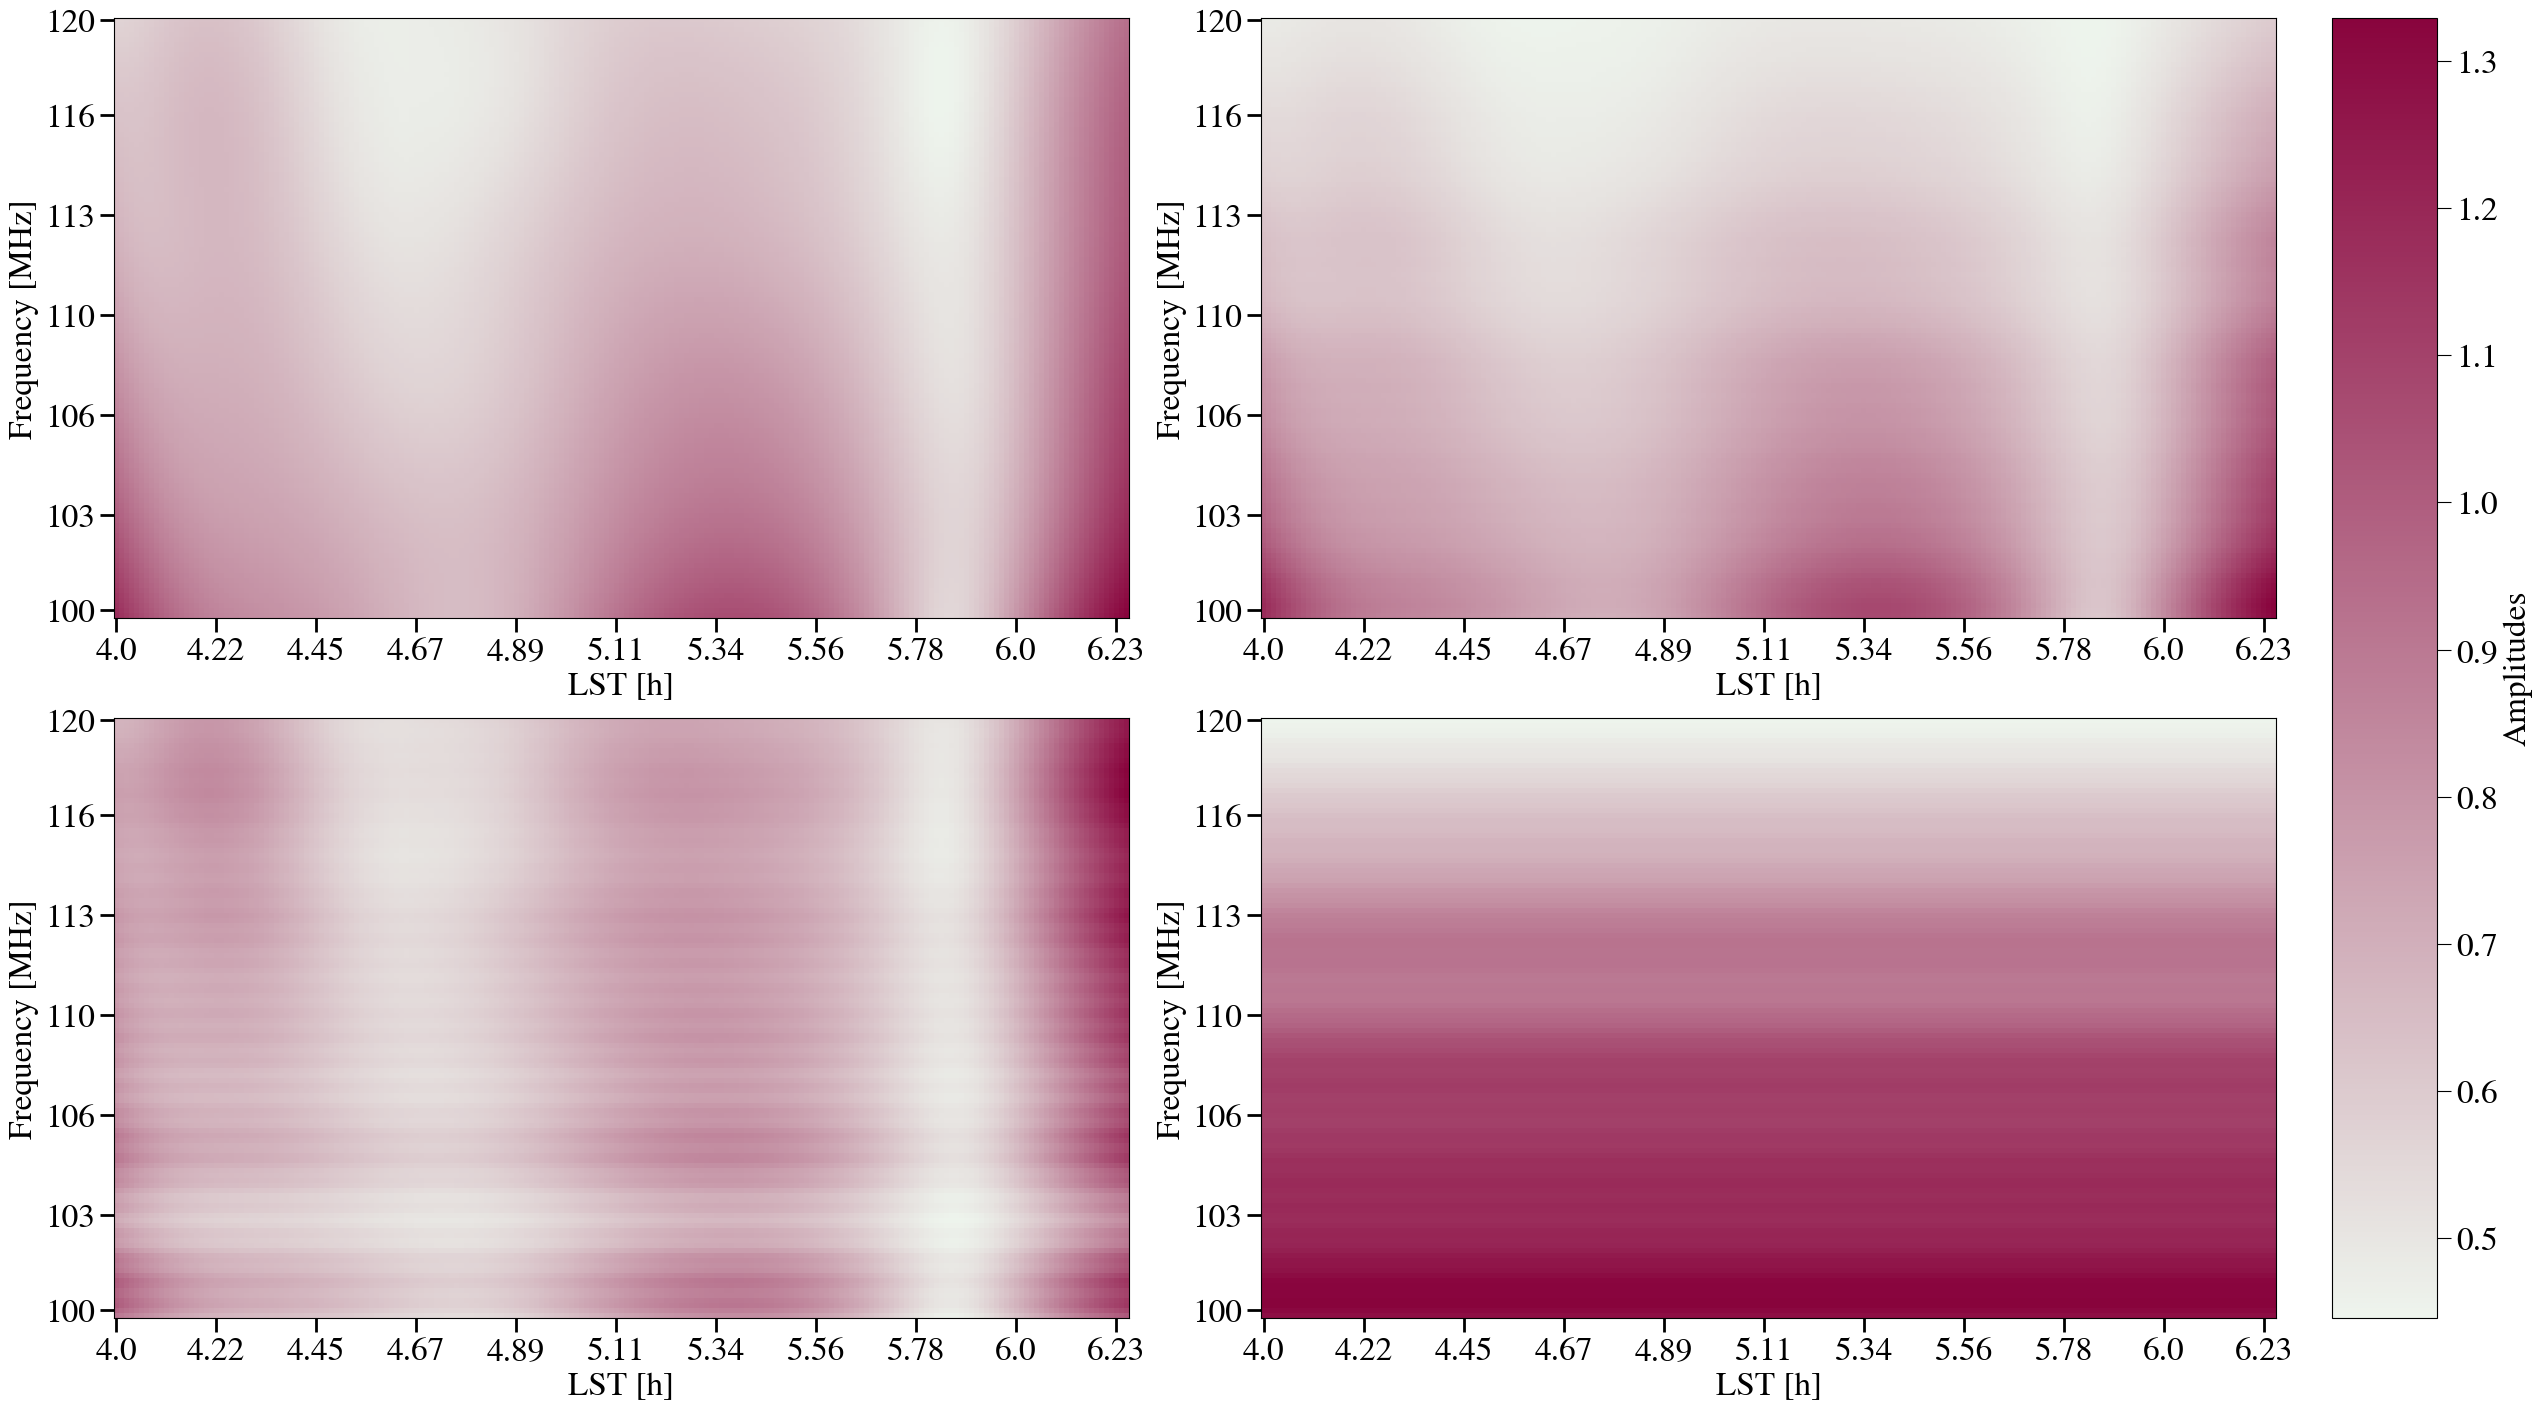

In [8]:
fig = plt.figure(figsize=(30., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.78, 0.65),
    nrows_ncols=(2, 2),
    axes_pad=1,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='all',
    aspect=False,
)
data_arr = np.array([[clean_vis, vis_corr], [vis_corr - clean_vis, vis_corr / clean_vis]])
a = 0
for i in range(2):
    for j in range(2):
        im = axs[a].imshow(np.abs(data_arr[i, j, :, :]).T, cmap=paper_map_pink, origin='lower')
        axs[a].set_ylabel('Frequency [MHz]')
        axs[a].set_xlabel('LST [h]')
        axs[a].tick_params(direction='out', length=6, width=2, colors='black', size=10)
        a += 1
cbar = axs.cbar_axes[0].colorbar(im, label='Amplitudes')
cbar.ax.tick_params(which='both', color='black', labelcolor='black', size=10)
for a in axs:
    a.set_yticks(xticklocs_full, labels=xticklabels_freqs_full)
    a.set_xticks(yticklocs_full, labels=yticklabels_times_full)
# plt.savefig(fig_dir + '/systematics_in_vis_space.pdf', bbox_inches='tight', dpi=300)

---
# Figure 3: Test case in delay–fringe-rate space

In [9]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_eor = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_eor = np.unique(uvd.lst_array)

uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-ptsrc-gsm.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_sky = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_sky = np.unique(uvd.lst_array)

# Full-band true sky of this run, corrupted by the true systematic model.
# Kept separate from the single-case arrays below (`_f3` suffix) so that
# re-running this cell cannot overwrite them.
eor_true_f3  = np.load(result_dir + run_version + '/eor_true.npy')[:Ntimes, :Nfreqs]
fg_true_f3   = np.load(parent_dir + 'res/npy_data/fg_true.npy')[:Ntimes, :Nfreqs]
data_true_f3 = eor_true_f3 + fg_true_f3
data_true_dlfr_full = dlfr(data_true_f3)


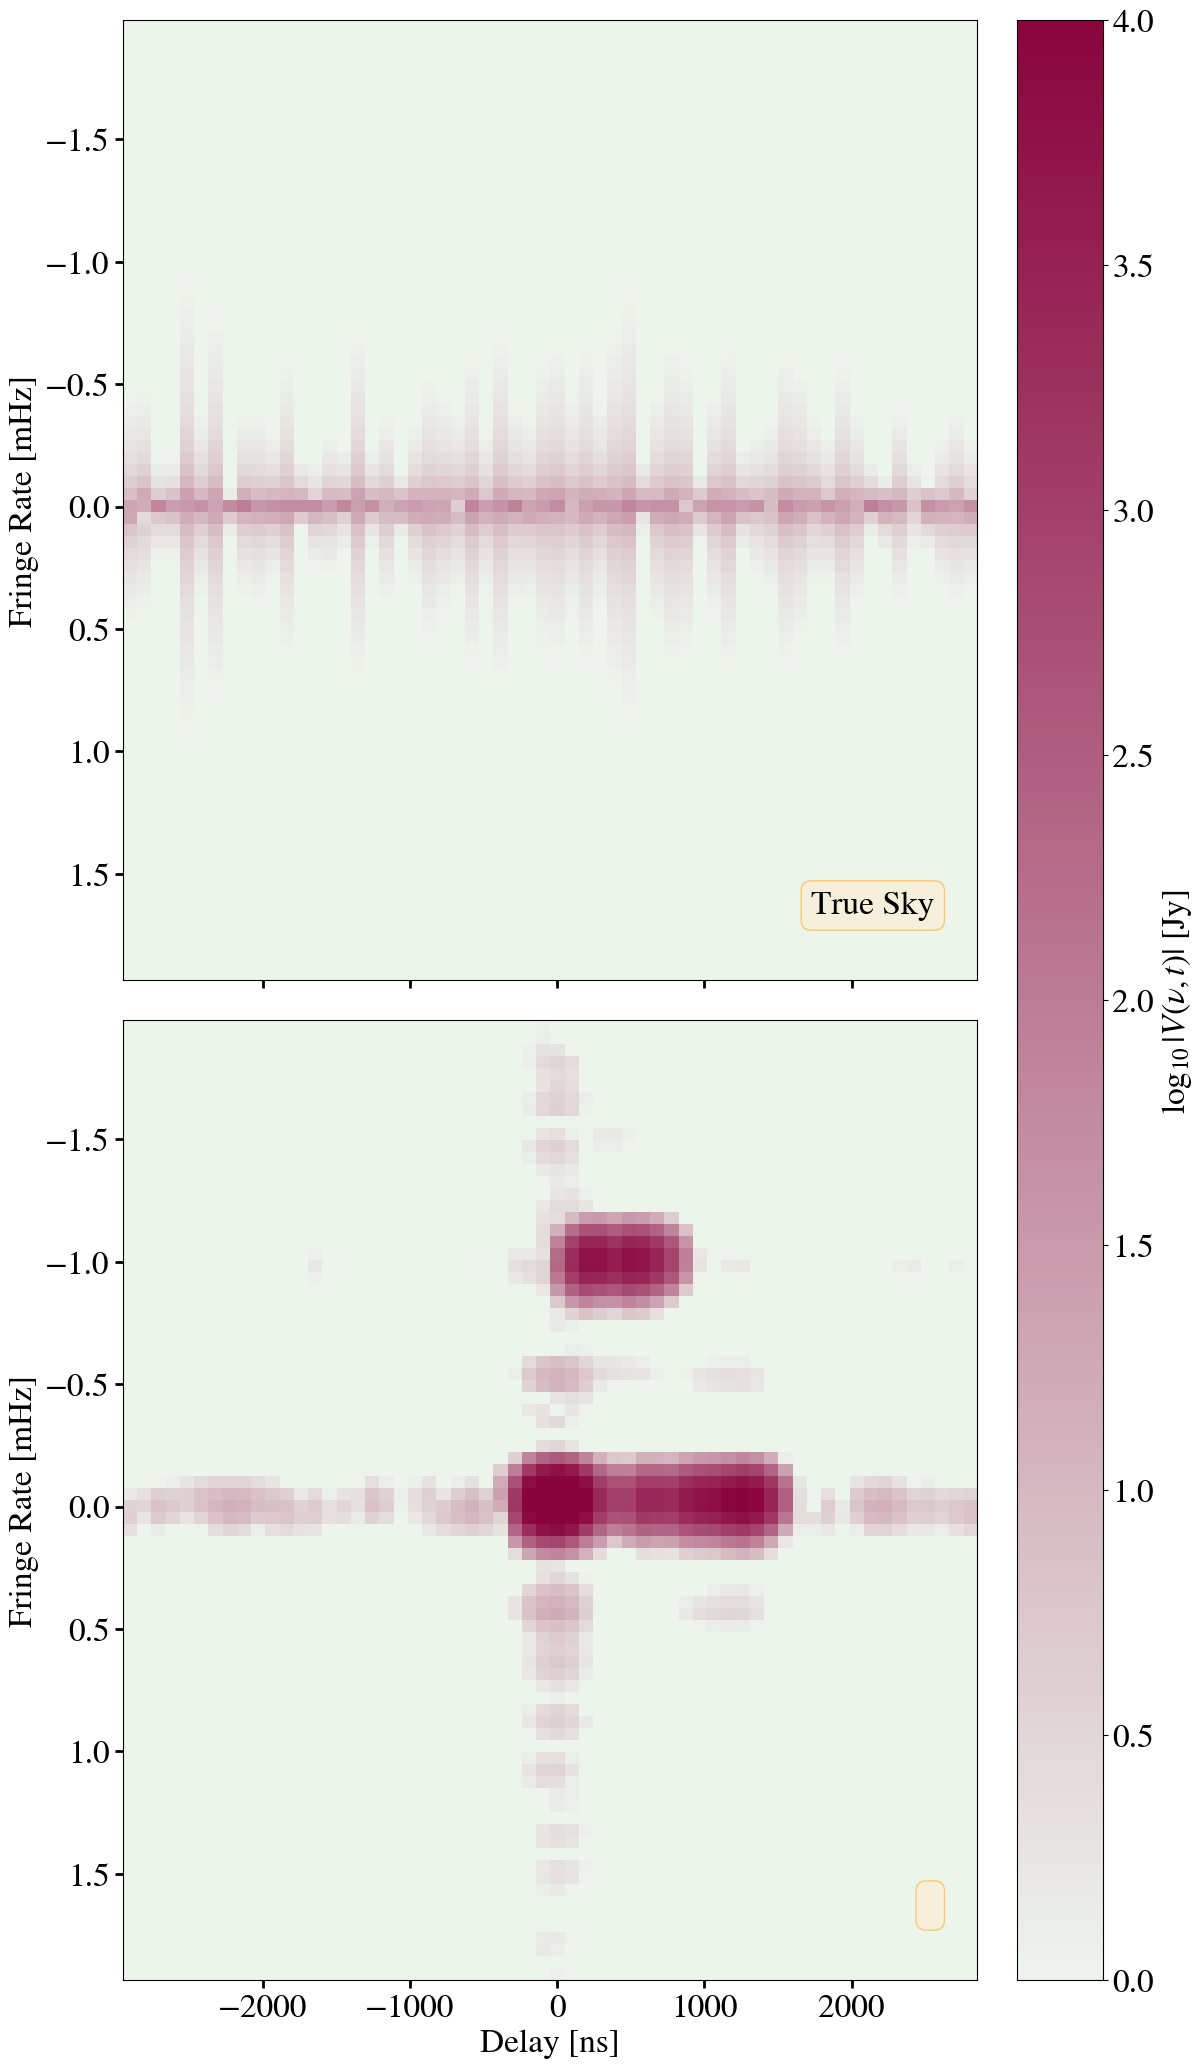

In [10]:
fig = plt.figure(figsize=(10., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.98, 0.98),
    nrows_ncols=(2, 1),
    axes_pad=0.4,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='L',
    aspect=False,
)

_ = plot_waterfalls(
    eor_true_f3, freqs * 1e6, lsts, fig=fig, ax=axs[0], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all',
    baseline=None, horizon_color='magenta', colorbar_flag=False,
)
axs[0].text(0.95, 0.07, 'True Sky', bbox=bbox, transform=axs[0].transAxes, horizontalalignment='right')

sys_model_true_f3 = (1 + sys_modes_operator @ sys_amps_true).reshape((Nfreqs, Ntimes)).T
total_data_dlfr   = dlfr(sys_model_true_f3 * data_true_f3)
plot_op = plot_waterfalls_from_dlfr(
    total_data_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs[1], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=False,
    baseline=None, horizon_color='magenta',
)
axs[1].text(0.95, 0.07, case_label, bbox=bbox, transform=axs[1].transAxes, horizontalalignment='right')

axs.cbar_axes[0].colorbar(plot_op, label=r'$\log_{10}|V(\nu, t)|$ [Jy]')
# plt.savefig(fig_dir + '/test_cases_in_dlfr.pdf', bbox_inches='tight', dpi=300)

---
# Sample processing

Loads the Gibbs samples of `run_version` and derives every statistic used by
Figures 4-11 in a single pass over the chain.  Means, standard deviations and
the Pearson map are accumulated online (Welford), so the pass needs no array
of per-iteration DLFR maps.

In [11]:
# The Gibbs chains are read row by row rather than held in memory: at
# Niter = 100000 gcr-eor.npy alone is ~7.7 GB.
_mmap = 'r' if USE_MMAP else None

fg_true        = np.load(result_dir + run_version + '/fg_true.npy')[:Ntimes, :Nfreqs]
fgmodes        = np.load(result_dir + run_version + '/fgmodes.npy')[:, :Nfgmodes]
fg_amps_gcr    = np.load(result_dir + run_version + '/fg-amps.npy', mmap_mode=_mmap)
eor_true       = np.load(result_dir + run_version + '/eor_true.npy')[:Ntimes, :Nfreqs]
eor_gcr        = np.load(result_dir + run_version + '/gcr-eor.npy', mmap_mode=_mmap)
ps_sample      = np.load(result_dir + run_version + '/dps-eor.npy')
ln_post        = np.load(result_dir + run_version + '/ln-post.npy')
b_sys_gcr      = np.load(result_dir + run_version + '/b-sys.npy')
sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')[:Ntimes, :Nfreqs]
data_true      = np.load(result_dir + run_version + '/data_true.npy')[:Ntimes, :Nfreqs]

print(f'{run_version}: {b_sys_gcr.shape[0]} samples on disk, '
      f'{fgmodes.shape[1]} foreground modes used, processing {Niter} iterations')
assert fg_amps_gcr.shape[-1] >= Nfgmodes, 'fewer foreground amplitudes than Nfgmodes'
assert b_sys_gcr.shape[0] >= Niter, 'fewer samples on disk than Niter'

delta_g_true = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
sky_true     = eor_true + fg_true

# ── Static DLFR quantities ────────────────────────────────────────────────────
sky_true_dlfr       = dlfr(sky_true)
sys_model_true_dlfr = dlfr(sys_model_true)
delta_g_dlfr_true   = dlfr(delta_g_true)
data_true_dlfr      = dlfr(data_true)

# ── Per-iteration power spectra (Figure 7 needs the full distribution) ───────
ps_fg  = np.empty((Niter, Nfreqs))
ps_sys = np.empty((Niter, Nfreqs))

# ── Online accumulators for the DLFR statistics ──────────────────────────────
# Welford updates, so no [Niter, Ntimes, Nfreqs] arrays are ever allocated
# (they came to ~7.7 GB each).  `*_M2` are the sums of |x - mean|^2 behind the
# standard deviations; `*_S2` / `fg_dg_S` are the un-conjugated sums of squares
# and cross-products behind the Pearson map, matching plot_crosscor_pearson.
_z  = lambda: np.zeros((Ntimes, Nfreqs), dtype='complex')
_zr = lambda: np.zeros((Ntimes, Nfreqs))

sky_mean, sky_M2 = _z(), _zr()   # Fig 5
dg_mean,  dg_M2  = _z(), _zr()   # Fig 6
fg_mean          = _z()          # Fig 11
fg_S2, dg_S2, fg_dg_S = _z(), _z(), _z()

# ── Single pass over the Gibbs samples ───────────────────────────────────────
print('Processing samples...')
for i in tqdm(range(Niter)):
    fg_vis = (fgmodes @ fg_amps_gcr[i][:, :Nfgmodes].T).T
    dg     = (sys_modes_operator @ b_sys_gcr[i]).reshape([Nfreqs, Ntimes]).T

    ps_fg[i]  = calc_ps(fg_vis)
    ps_sys[i] = calc_ps(1 + dg)

    sky_d = dlfr(eor_gcr[i] + fg_vis)
    fg_d  = dlfr(fg_vis)
    dg_d  = dlfr(dg)

    k = i + 1
    # Sky: mean and standard deviation
    d_sky     = sky_d - sky_mean
    sky_mean += d_sky / k
    sky_M2   += (np.conj(d_sky) * (sky_d - sky_mean)).real

    # Foregrounds and systematics: means, standard deviation and cross-products.
    # The Pearson map is invariant to the constant dlfr_ones offset of the
    # systematic model, so DLFR(dg) is accumulated instead of DLFR(1 + dg).
    d_fg_old  = fg_d - fg_mean
    d_dg_old  = dg_d - dg_mean
    fg_mean  += d_fg_old / k
    dg_mean  += d_dg_old / k
    d_fg_new  = fg_d - fg_mean
    d_dg_new  = dg_d - dg_mean

    dg_M2    += (np.conj(d_dg_old) * d_dg_new).real
    fg_S2    += d_fg_old * d_fg_new
    dg_S2    += d_dg_old * d_dg_new
    fg_dg_S  += d_fg_old * d_dg_new

# ── True power spectra ────────────────────────────────────────────────────────
eor_pspec_true = calc_ps(eor_true)
fg_pspec_true  = calc_ps(fg_true)
sys_pspec_true = calc_ps(sys_model_true)
n_pspec        = calc_ps(n.T)

# ── DLFR statistics ───────────────────────────────────────────────────────────
mean_sky_dlfr       = sky_mean
std_sky_dlfr        = np.sqrt(sky_M2 / Niter)
res_sky_dlfr        = sky_true_dlfr - mean_sky_dlfr

delta_g_dlfr_mean   = dg_mean
delta_g_dlfr_std    = np.sqrt(dg_M2 / Niter)
sys_model_dlfr_mean = dlfr_ones + delta_g_dlfr_mean   # linearity: DLFR(1+dg) = dlfr_ones + DLFR(dg)
res_sys_dlfr        = sys_model_true_dlfr - sys_model_dlfr_mean

# Pearson r between the foreground and systematic DLFR samples (Fig 11)
corr_map = fg_dg_S / np.sqrt(fg_S2 * dg_S2)

print('Done.')

caseiv: 100000 samples on disk, 10 foreground modes used, processing 100000 iterations
Processing samples...


  0%|          | 0/100000 [00:00<?, ?it/s]

100%|██████████| 100000/100000 [01:09<00:00, 1445.38it/s]

Done.


---
# Figure 4: Data vs sky

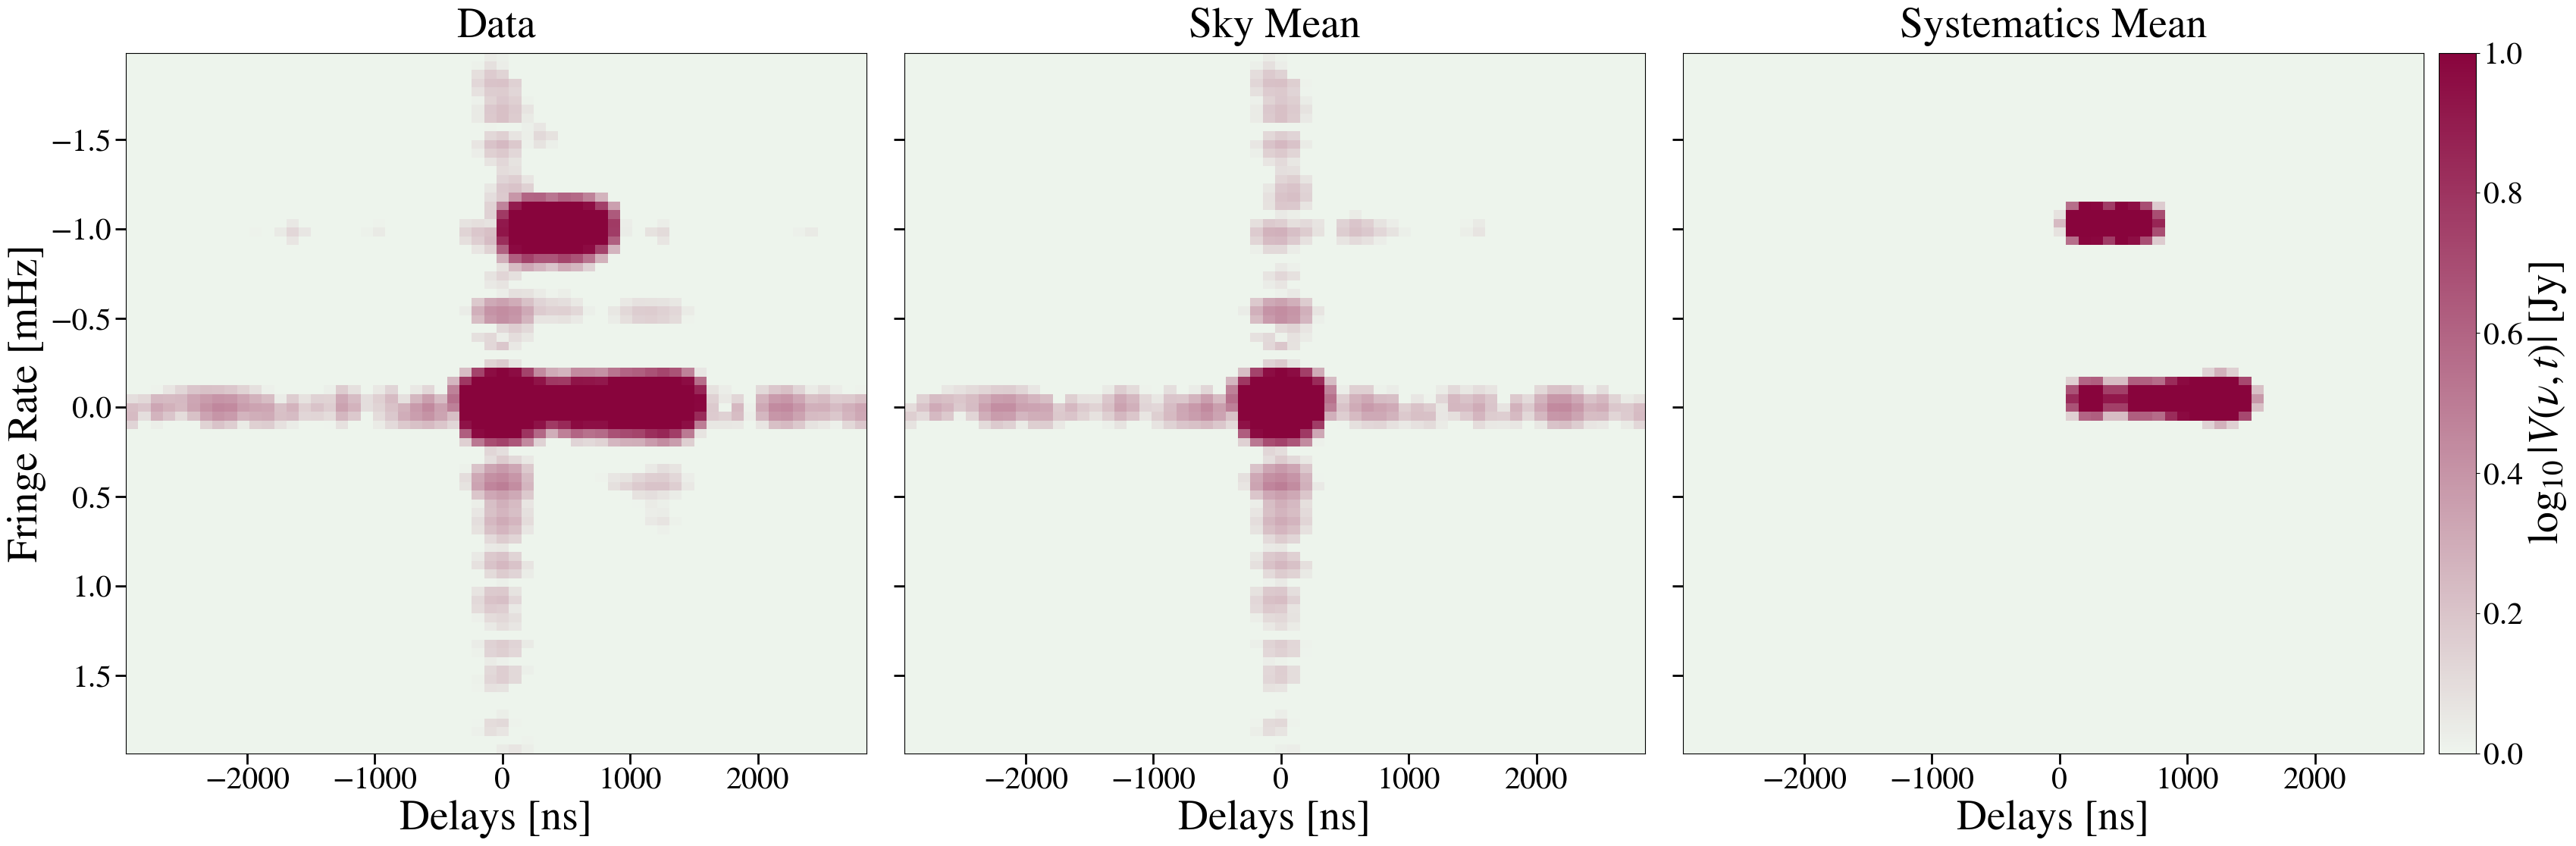

In [12]:
fig = plt.figure(figsize=(40, 12))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(1, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

im0 = plot_waterfalls_from_dlfr(
    data_true_dlfr, freqs * 1e6, lsts, fig=fig, ax=ax[0], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)
im1 = plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=ax[1], mode='log',
    vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)
im2 = plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs * 1e6, lsts, fig=fig, ax=ax[2], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=dynamic_range,
    limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
)

fig_titles = ['Data', 'Sky Mean', 'Systematics Mean']
for i, a in enumerate(ax):
    a.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=30)
    a.set_xlabel('Delays [ns]', fontsize=40)
    a.set_ylabel('Fringe Rate [mHz]', fontsize=40)
    a.set_title(fig_titles[i], fontsize=40, pad=15)
cbar = ax.cbar_axes[0].colorbar(im2)
cbar.set_label(r'$\log_{10}|V(\nu, t)|$ [Jy]', size=40)
cbar.ax.tick_params(labelsize=30)
# plt.savefig(fig_dir + '/data_vs_sky_2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 5: Sky result waterfalls

True / mean / standard deviation / residuals of the sky visibilities.

Text(0.5, 0.93, ' ')

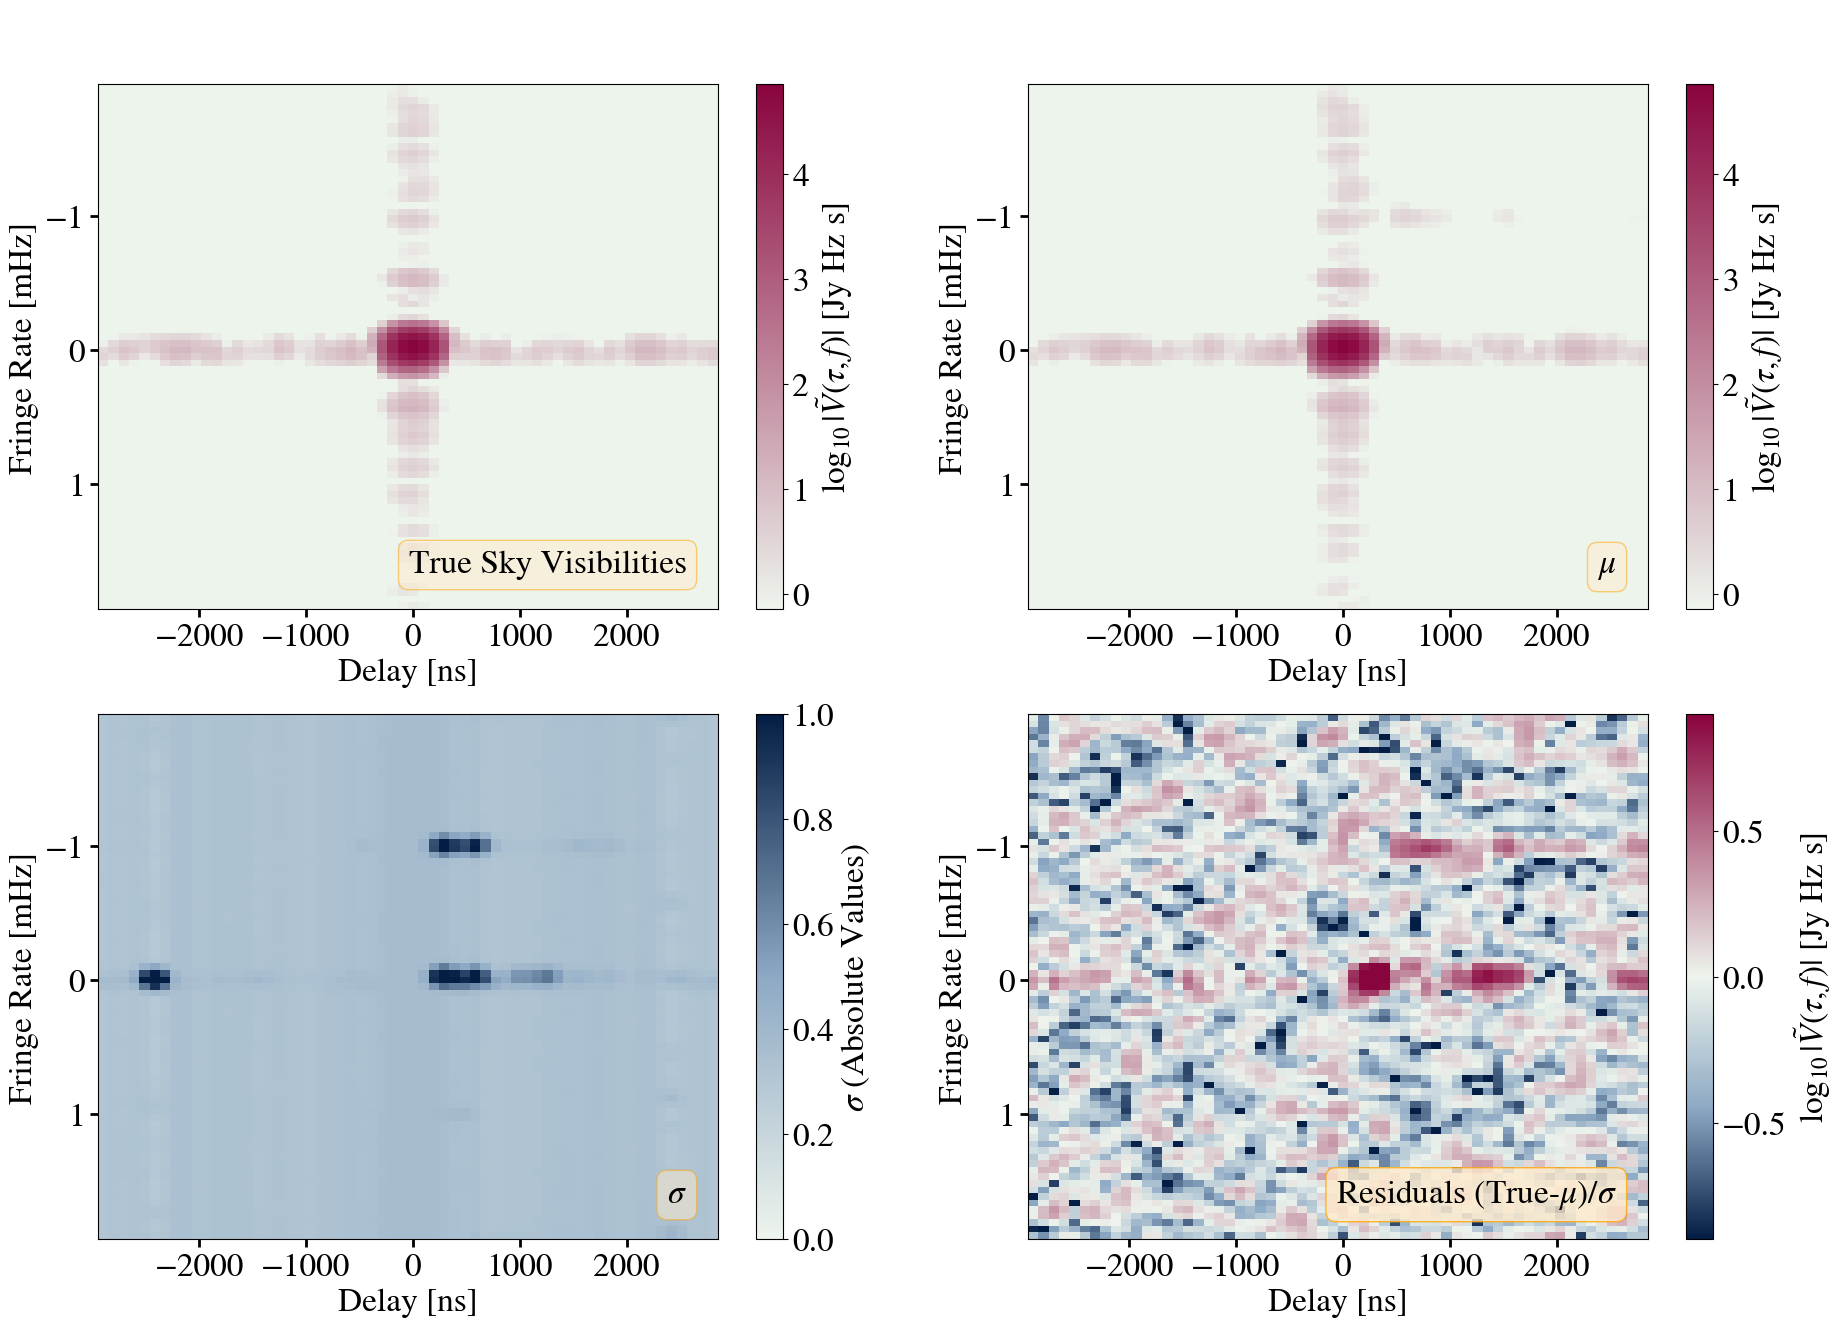

In [13]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    sky_true_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Sky Visibilities', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    std_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=1, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    res_sky_dlfr/std_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[3], mode='log',
    vmin=-0.9, vmax=0.9, cmap=paper_map, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')/'+r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')

fig.suptitle(case_label, y=0.93)
# plt.savefig(fig_dir + '/result_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figure 6: Systematics result waterfalls

True / mean / standard deviation / residuals of the systematic model.

Text(0.5, 0.93, ' ')

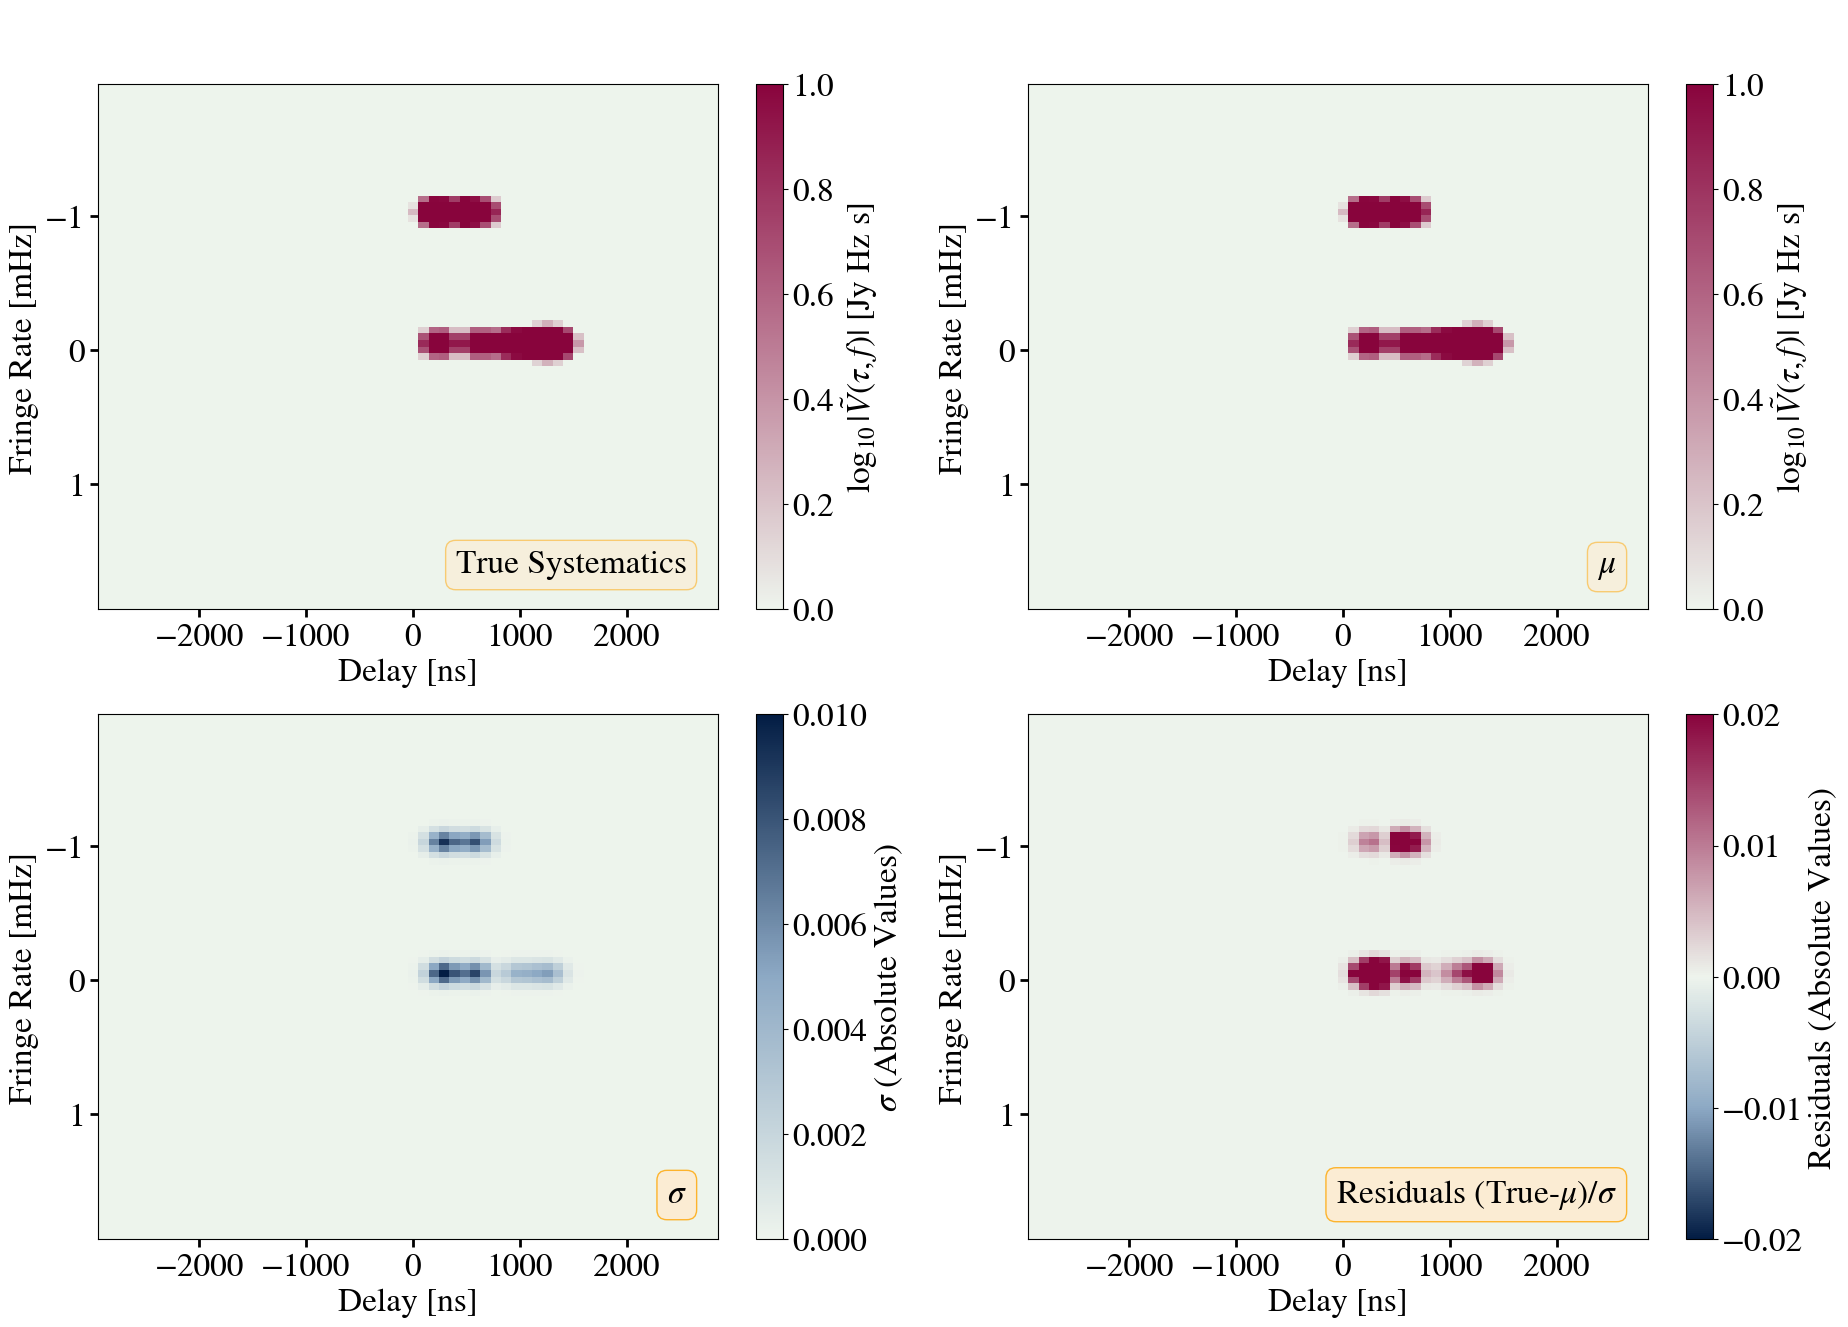

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    delta_g_dlfr_true, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Systematics', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_std, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=0.01, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    res_sys_dlfr/(1+delta_g_dlfr_std), freqs * 1e6, lsts,
    fig=fig, ax=axs.flatten()[3], mode='abs', vmin=-0.02, vmax=0.02, cmap=paper_map,
    dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label='Residuals (Absolute Values)',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')/'+r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')

fig.suptitle(case_label, y=0.93)
# plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figure 7: Fractional errors by component

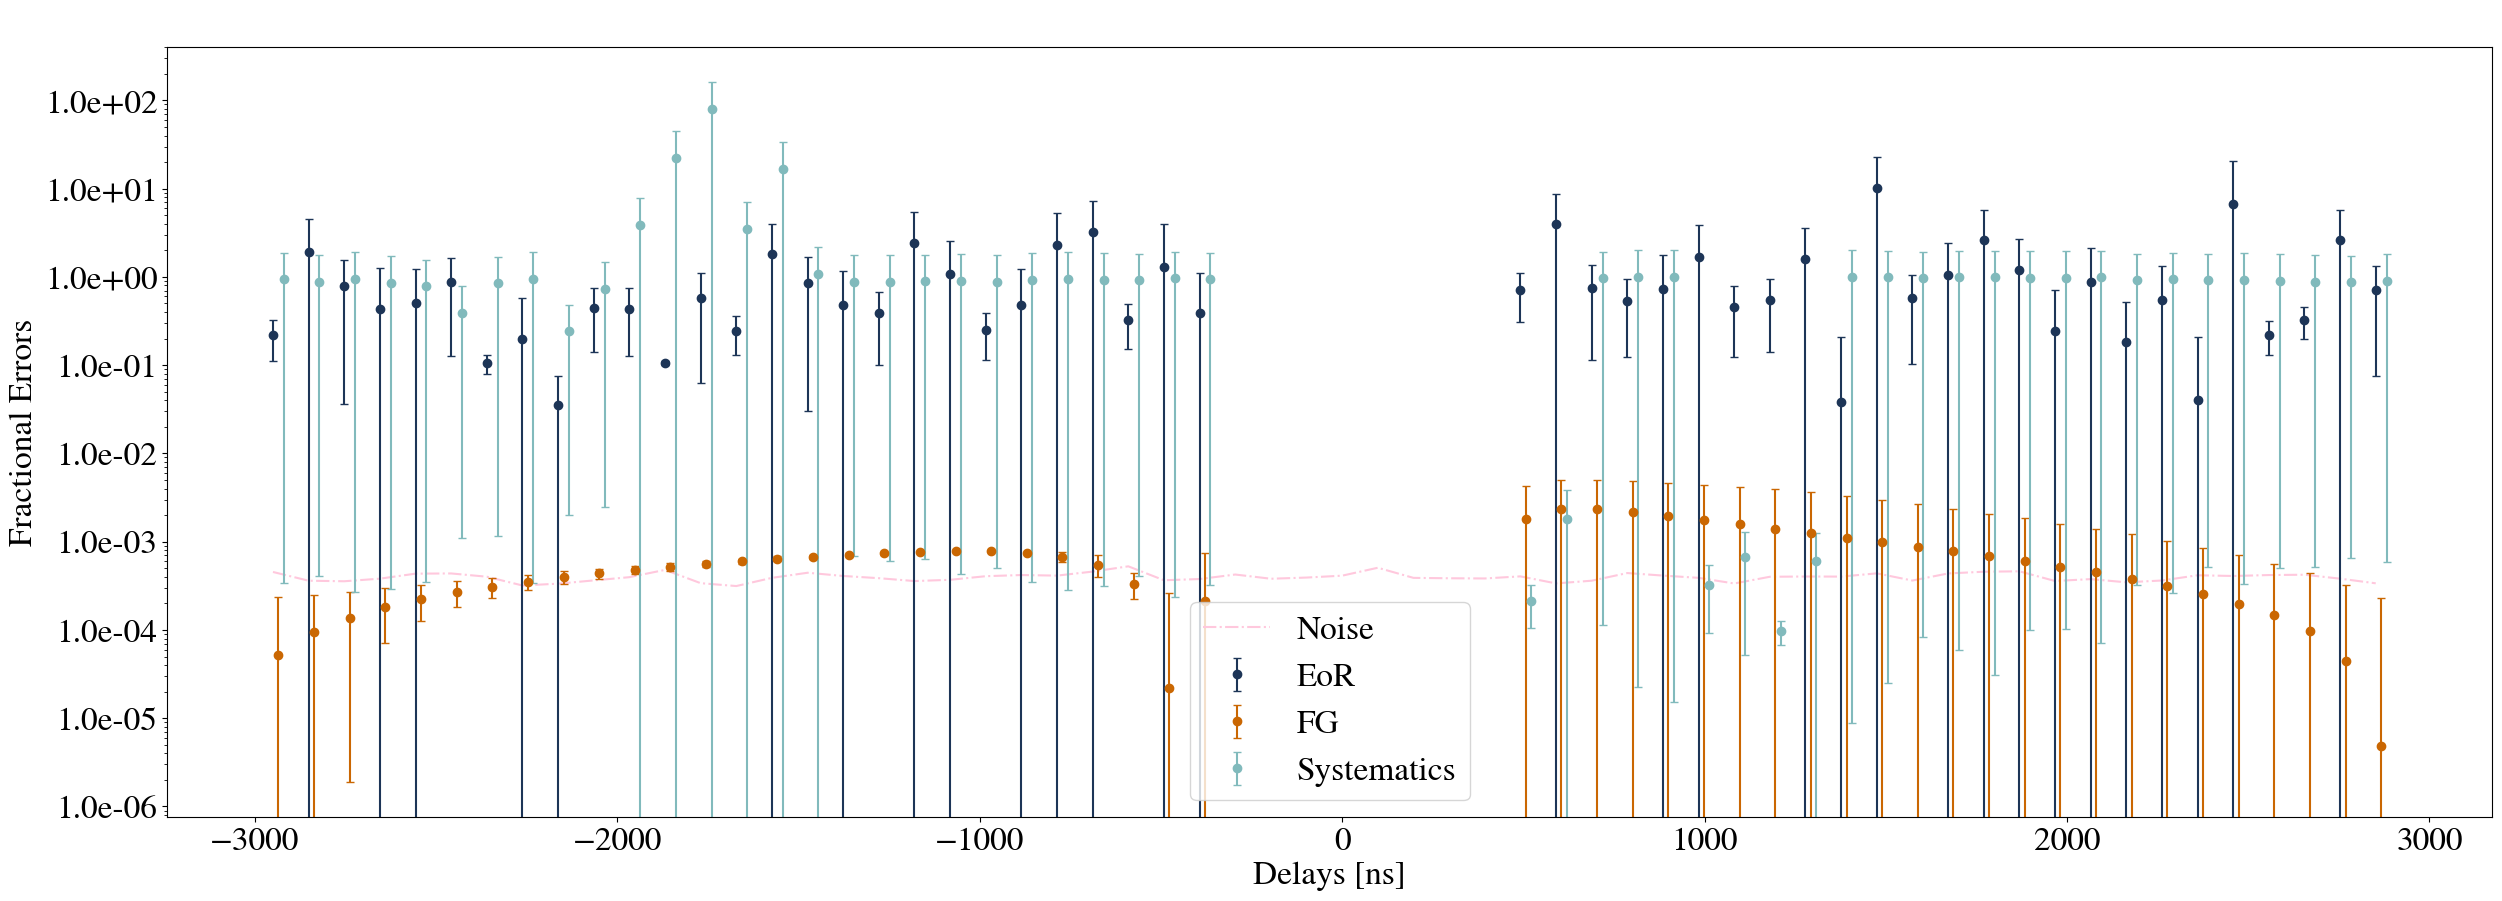

In [15]:
fig, axs = plt.subplots(1, 1, figsize=(30, 10))

data_arr_errs = [
    (eor_pspec_true - ps_sample[:Niter]) / eor_pspec_true,
    (fg_pspec_true  - ps_fg)             / fg_pspec_true,
    (sys_pspec_true - ps_sys)            / sys_pspec_true,
]
plot_arr = [d.mean(axis=0) for d in data_arr_errs]
fig_labels_err = ['EoR', 'FG', 'Systematics', 'Noise']

rm   = np.arange(27, 35)   # delay bins masked out (foreground-dominated)
keep = np.ones(len(plot_arr[0]), dtype=bool)
keep[rm] = False

axs.plot(delays, np.abs(n_pspec), ls='-.', c=colors[-1], label=fig_labels_err[-1])

for i in range(3):
    pa = plot_arr[i][keep]
    da = data_arr_errs[i][:, keep]
    std  = np.std(np.abs(da), axis=0)
    errs = np.vstack((pa - std, std - pa))
    axs.errorbar(
        delays[keep].value + (i * 15), np.abs(pa),
        yerr=np.abs(errs), fmt='o', color=colors[i], label=fig_labels_err[i], capsize=3,
    )

axs.legend()
axs.set_title(case_label)
axs.set_yscale('log')
axs.set_xlabel('Delays [ns]')
axs.set_ylabel('Fractional Errors')
axs.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
# plt.savefig(fig_dir + '/errors_components.pdf', bbox_inches='tight', dpi=300)

---
# Figure 8: Corner plot of the systematic amplitudes

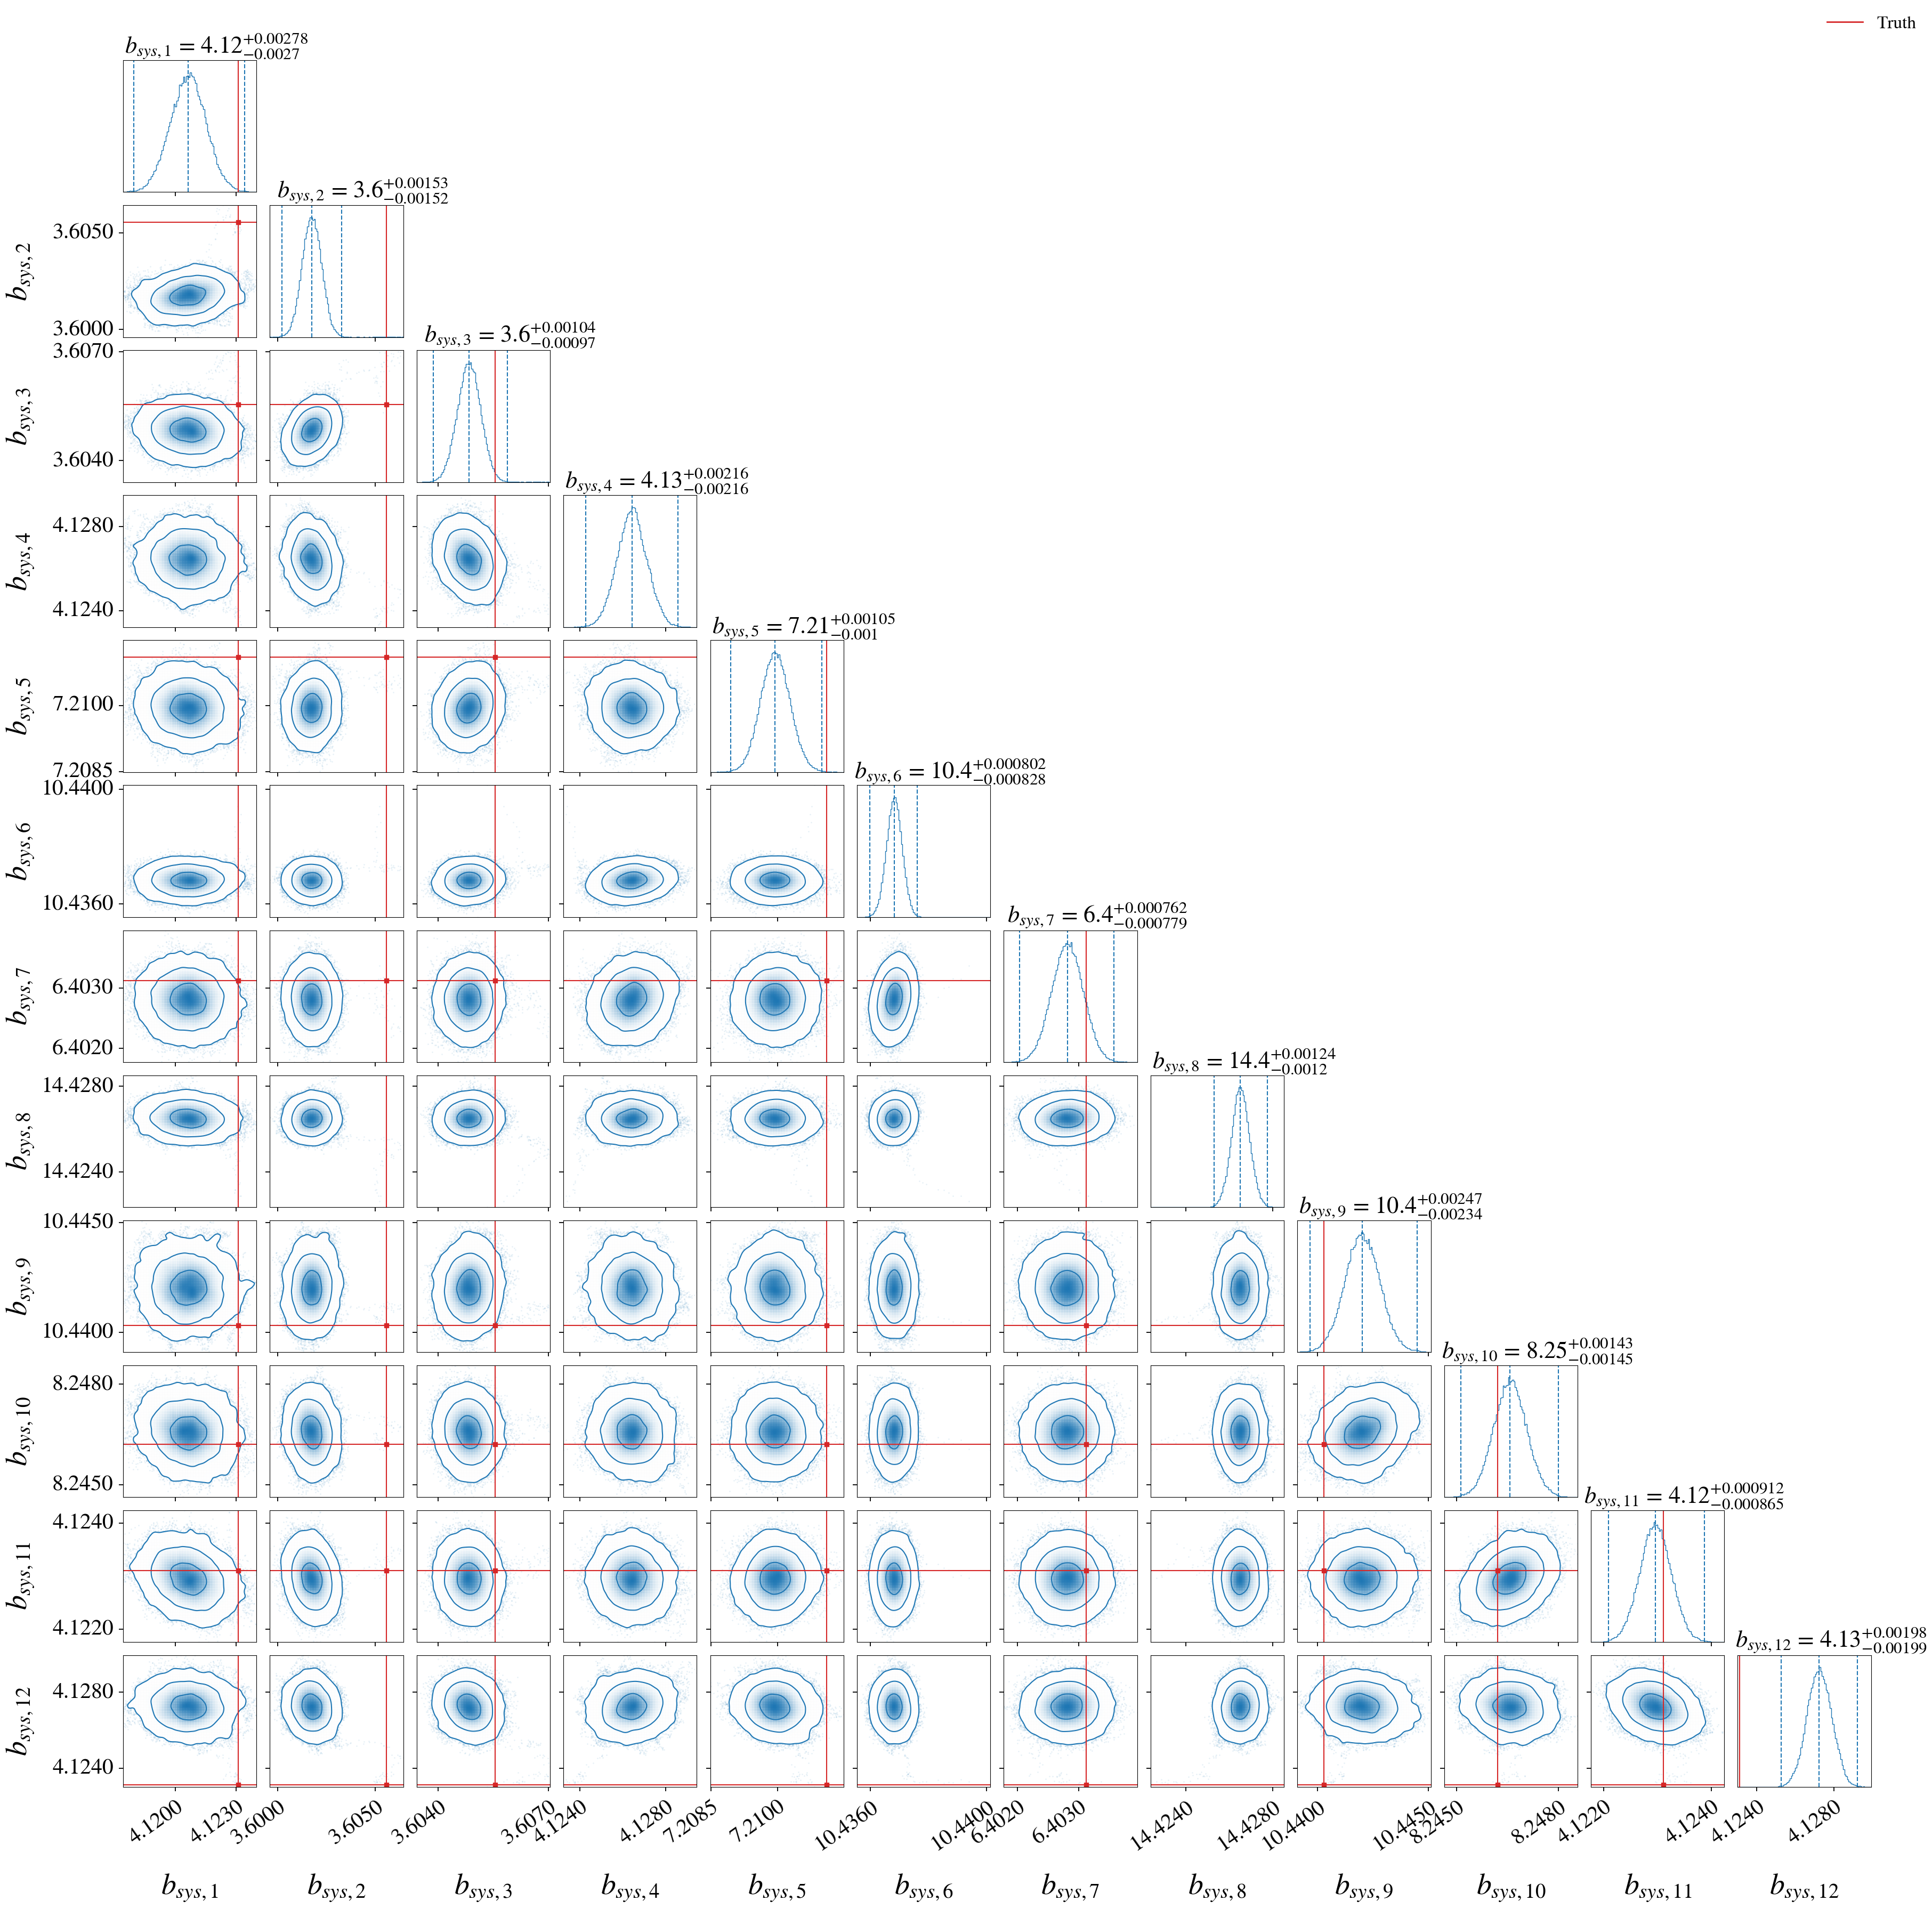

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import corner


def corner_plot(
    samples,
    labels=None,
    truths=None,
    burn=0,
    thin=1,
    fig=None,

    truths_label="Truth",

    extra_truths=None,
    extra_color="tab:green",
    extra_truths_label="Truth B",

    title=None,
    legend_loc="upper right",

    nsigma=3,

    # ---------------------------------------------------------
    # Font sizes
    # ---------------------------------------------------------
    label_fontsize=32,
    tick_fontsize=22,
    title_fontsize=22,
    legend_fontsize=24,

    # Number of candidate ticks before edge pruning
    max_n_ticks=3,

    # Large figure is necessary for 12 parameters + large fonts
    fig_size_inches=40,

    # ---------------------------------------------------------
    # Layout
    # ---------------------------------------------------------
    margin_left=0.16,
    margin_right=0.98,
    margin_bottom=0.16,
    margin_top=0.97,

    wspace=0.10,
    hspace=0.10,

    # Explicit parameter-label locations in axes coordinates.
    # These matter much more than labelpad here.
    xlabel_y=-0.52,
    ylabel_x=-0.52,

    # ---------------------------------------------------------
    # Tick formatting
    # ---------------------------------------------------------
    tick_decimals=4,
    xtick_rotation=35,
):

    # =========================================================
    # Samples
    # =========================================================
    S = samples[burn::thin]
    ndim = S.shape[1]

    # =========================================================
    # Confidence levels
    # =========================================================
    levels = [
        1.0 - np.exp(-0.5 * n**2)
        for n in range(1, nsigma + 1)
    ]

    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]

    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]

    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]

    else:
        raise ValueError(
            "nsigma must be 1, 2, or 3."
        )

    # =========================================================
    # Figure
    # =========================================================
    if fig is None:
        fig = plt.figure(
            figsize=(
                fig_size_inches,
                fig_size_inches,
            )
        )

    # =========================================================
    # Corner plot
    # =========================================================
    fig = corner.corner(
        S,

        labels=labels,

        truths=truths,
        truth_color="tab:red",

        quantiles=quantiles,
        levels=levels,

        fig=fig,

        show_titles=True,
        title_fmt=".3g",

        bins=100,
        smooth=2.0,
        color="C0",

        max_n_ticks=max_n_ticks,

        label_kwargs={
            "fontsize": label_fontsize,
        },

        title_kwargs={
            "fontsize": title_fontsize,
        },
    )

    # =========================================================
    # Optional second truth
    # =========================================================
    if extra_truths is not None:

        corner.overplot_lines(
            fig,
            extra_truths,
            color=extra_color,
            linewidth=1.6,
        )

        corner.overplot_points(
            fig,
            [extra_truths],
            color=extra_color,
            marker="s",
            ms=5,
        )

    # =========================================================
    # Axes
    # =========================================================
    axes = np.asarray(
        fig.axes[:ndim * ndim]
    ).reshape(
        ndim,
        ndim,
    )

    # =========================================================
    # Formatter factory
    # =========================================================
    def make_formatter():

        if tick_decimals is not None:

            return mticker.FormatStrFormatter(
                f"%.{tick_decimals}f"
            )

        formatter = mticker.ScalarFormatter(
            useOffset=False
        )

        formatter.set_scientific(False)

        return formatter

    # =========================================================
    # First hide ALL tick labels.
    #
    # This prevents corner's own defaults from leaking through.
    # =========================================================
    for i in range(ndim):

        for j in range(ndim):

            ax = axes[i, j]

            ax.tick_params(
                axis="x",
                labelbottom=False,
                labeltop=False,
            )

            ax.tick_params(
                axis="y",
                labelleft=False,
                labelright=False,
            )

            ax.xaxis.get_offset_text().set_visible(False)
            ax.yaxis.get_offset_text().set_visible(False)

    # =========================================================
    # Format active lower-triangle panels
    # =========================================================
    for i in range(ndim):

        for j in range(i + 1):

            ax = axes[i, j]

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=tick_fontsize,
                length=6,
                width=1.3,
                pad=7,
                direction="out",
            )

            # -------------------------------------------------
            # Interior panels:
            # keep ticks themselves if desired,
            # but do NOT display numbers.
            # -------------------------------------------------

            # =================================================
            # BOTTOM ROW: x tick numbers only
            # =================================================
            if i == ndim - 1:

                # IMPORTANT:
                # prune='both' removes ticks close to the left
                # and right boundaries of every little panel.
                #
                # This prevents:
                #
                #   4.1230 3.6000
                #
                # from colliding between neighbouring panels.
                ax.xaxis.set_major_locator(
                    mticker.MaxNLocator(
                        nbins=max_n_ticks,
                        prune="both",
                    )
                )

                ax.xaxis.set_major_formatter(
                    make_formatter()
                )

                ax.tick_params(
                    axis="x",
                    labelbottom=True,
                )

                plt.setp(
                    ax.get_xticklabels(),
                    rotation=xtick_rotation,
                    ha="right",
                    rotation_mode="anchor",
                )

            # =================================================
            # LEFT COLUMN: y tick numbers only
            # =================================================
            if j == 0 and i > 0:

                # Again prune boundary ticks.
                #
                # This keeps labels away from the horizontal
                # borders between adjacent rows.
                ax.yaxis.set_major_locator(
                    mticker.MaxNLocator(
                        nbins=max_n_ticks,
                        prune="both",
                    )
                )

                ax.yaxis.set_major_formatter(
                    make_formatter()
                )

                ax.tick_params(
                    axis="y",
                    labelleft=True,
                )

                # Horizontal y tick labels are substantially
                # easier to fit than rotated ones.
                plt.setp(
                    ax.get_yticklabels(),
                    rotation=0,
                    ha="right",
                    va="center",
                )

    # =========================================================
    # Bottom parameter labels
    # =========================================================
    for j in range(ndim):

        ax = axes[-1, j]

        ax.xaxis.label.set_fontsize(
            label_fontsize
        )

        # Explicit position rather than labelpad
        ax.xaxis.set_label_coords(
            0.5,
            xlabel_y,
        )

    # =========================================================
    # Left parameter labels
    # =========================================================
    for i in range(1, ndim):

        ax = axes[i, 0]

        ax.yaxis.label.set_fontsize(
            label_fontsize
        )

        # Explicitly place the parameter label farther left
        # than the tick numbers.
        ax.yaxis.set_label_coords(
            ylabel_x,
            0.5,
        )

    # =========================================================
    # Diagonal titles
    # =========================================================
    #
    # These strings are physically much wider than the panels,
    # so keep their font smaller than the outer parameter labels.
    #
    for i in range(ndim):

        ax = axes[i, i]

        ax.title.set_fontsize(
            title_fontsize
        )

        # Put title slightly above its own panel.
        ax.title.set_position(
            (0.7, 1.03)
        )

    # =========================================================
    # Layout
    # =========================================================
    fig.subplots_adjust(
        left=margin_left,
        right=margin_right,
        bottom=margin_bottom,
        top=margin_top,
        wspace=wspace,
        hspace=hspace,
    )

    # =========================================================
    # Legend
    # =========================================================
    legend_handles = []

    if truths is not None:

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color="tab:red",
                lw=2.0,
                label=truths_label,
            )
        )

    if extra_truths is not None:

        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=extra_color,
                lw=2.0,
                label=extra_truths_label,
            )
        )

    if legend_handles:

        fig.legend(
            handles=legend_handles,
            loc=legend_loc,
            frameon=False,
            fontsize=legend_fontsize,
        )

    # =========================================================
    # Overall title
    # =========================================================
    if title:

        fig.suptitle(
            title,
            y=0.995,
            fontsize=title_fontsize + 4,
        )

    return fig

fig = corner_plot(
    np.abs(b_sys_gcr),

    truths=np.abs(sys_amps_true),

    labels=[
        rf"$b_{{sys,{i}}}$"
        for i in range(1, 13)
    ],

    nsigma=3,

    fig_size_inches=40,

    label_fontsize=40,
    tick_fontsize=30,

    # Keep these smaller because the diagonal title strings
    # are much longer than an ordinary parameter label.
    title_fontsize=32,

    max_n_ticks=1,

    xlabel_y=-0.65,
    ylabel_x=-0.65,
)
plt.savefig(fig_dir + '/multi_corner_plot.pdf', bbox_inches='tight', dpi=150)

---
# Figure 9: Systematics fractional error

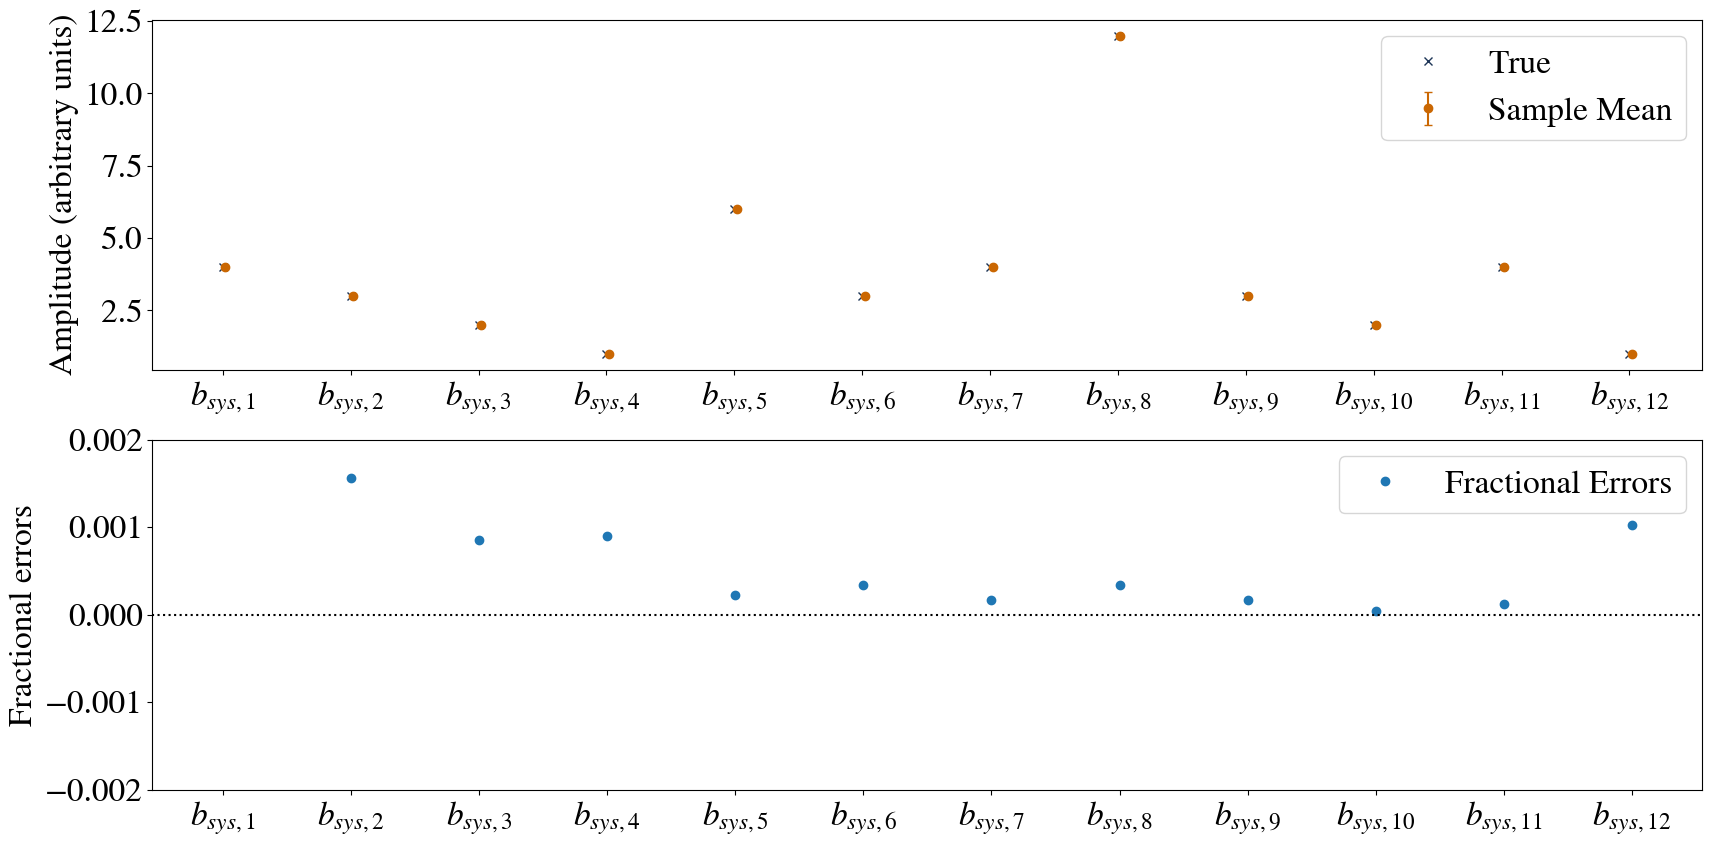

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

errs = np.vstack((
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
))

ax[0].plot(np.imag(sys_amps_true), 'x', c=colors[0], label='True')
ax[0].errorbar(
    [0.02, 1.02, 2.02, 3.02, 4.02, 5.02, 6.02, 7.02, 8.02, 9.02, 10.02, 11.02], np.imag(b_sys_gcr.mean(axis=0)),
    fmt='o', yerr=errs, label='Sample Mean', capsize=3, c=colors[1],
)
ax[0].set_ylabel('Amplitude (arbitrary units)')
ax[0].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$',r'$b_{sys,5}$', r'$b_{sys,6}$', r'$b_{sys,7}$', r'$b_{sys,8}$',r'$b_{sys,9}$', r'$b_{sys,10}$', r'$b_{sys,11}$', r'$b_{sys,12}$'])
ax[0].legend()

res_mean = np.abs(sys_amps_true - b_sys_gcr.mean(axis=0)) / np.abs(sys_amps_true)
ax[1].plot([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], res_mean, 'o', label='Fractional Errors')
ax[1].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$',r'$b_{sys,5}$', r'$b_{sys,6}$', r'$b_{sys,7}$', r'$b_{sys,8}$',r'$b_{sys,9}$', r'$b_{sys,10}$', r'$b_{sys,11}$', r'$b_{sys,12}$'])
ax[1].axhline(0, c='k', ls='dotted')
ax[1].set_ylabel('Fractional errors')
ax[1].set_ylim(-0.002, 0.002)
ax[1].legend()
# plt.savefig(fig_dir + '/sys_frac_error.pdf', bbox_inches='tight', dpi=300)

---
# Figure 10: Delay power spectrum

In [18]:
zoom

NameError: name 'zoom' is not defined

Max fractional error: 10.21905482056772


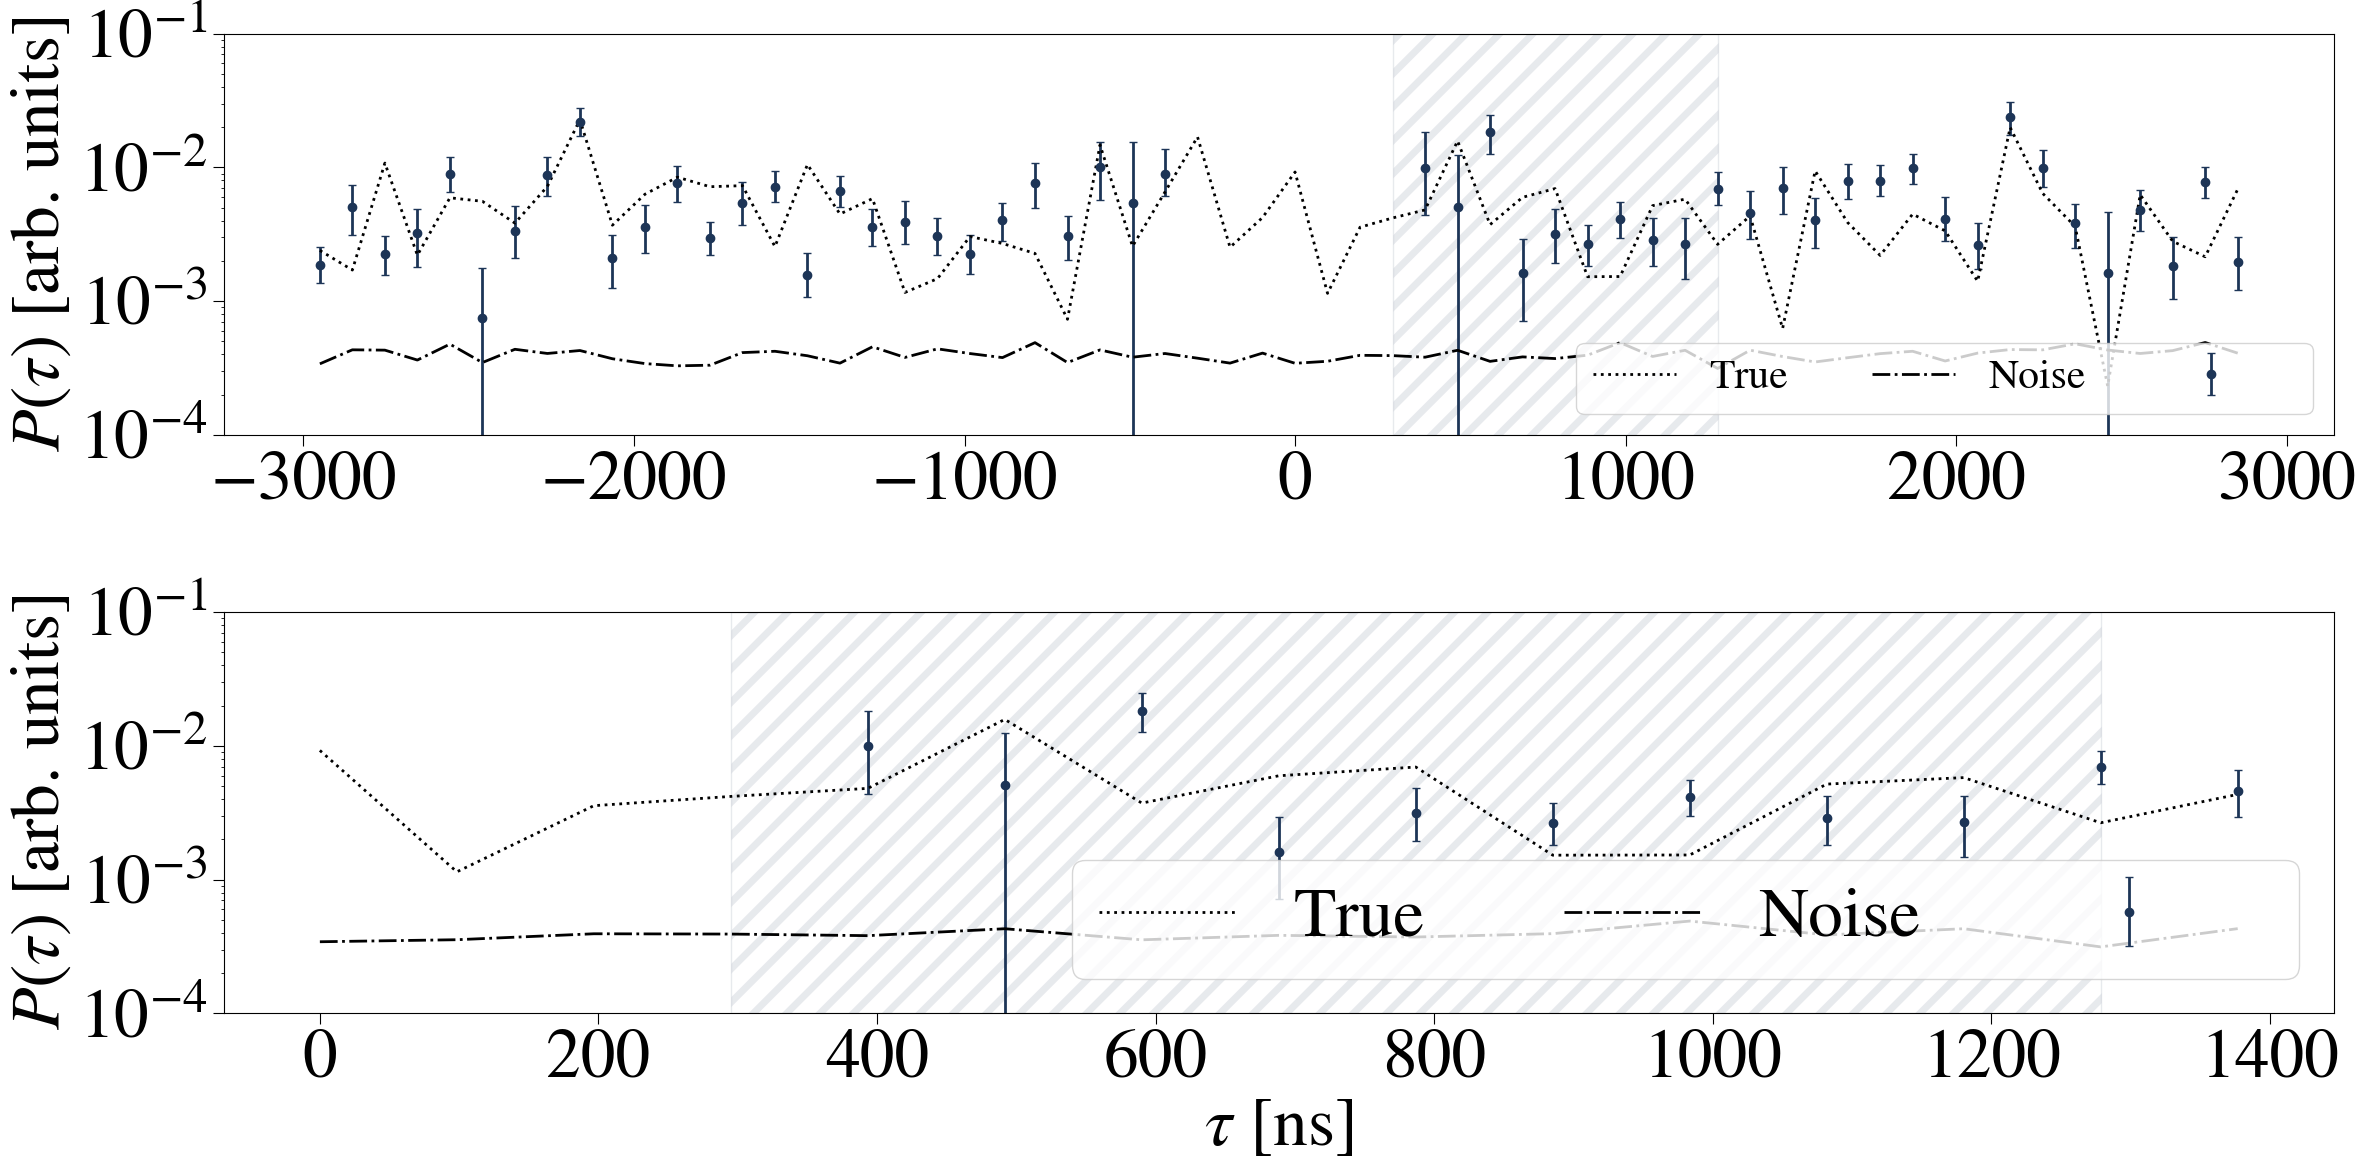

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(25, 13))

sys_delays = delays[np.unique(dl_ind) + int(Nfreqs / 2)].value

ps_sample_plot = ps_sample[Nburn:Niter]
ln_post_plot   = ln_post[Nburn:Niter]

dps_pwm    = np.average(ps_sample_plot, weights=ln_post_plot, axis=0)
percentile = conf_interval / 2 + 50
dps_ubound = np.percentile(ps_sample_plot, percentile,       axis=0)
dps_lbound = np.percentile(ps_sample_plot, 100 - percentile, axis=0)
dps_err    = np.vstack((dps_pwm - dps_lbound, dps_ubound - dps_pwm))

ax[0].errorbar(
    delays.value, dps_pwm, yerr=np.abs(dps_err),
    color=colors[0], ls='', marker='o', elinewidth=2, capsize=3, label=case_label,
)

x0, x1 = np.min(sys_delays), np.max(sys_delays)
ax[0].axvspan(x0, x1, facecolor='none', ec=colors[0], hatch='/', hatch_linewidth=5, alpha=0.1, zorder=0.1)
ax[1].axvspan(x0, x1, facecolor='none', ec=colors[0], hatch='/', hatch_linewidth=5, alpha=0.1, zorder=0.1)

zoom = slice(30, 45)
ax[1].errorbar(
    delays[zoom].value, dps_pwm[zoom], yerr=np.abs(dps_err[:, zoom]),
    color=colors[0], ls='', marker='o', elinewidth=2, capsize=3, label=case_label,
)
print('Max fractional error:', max((dps_pwm - eor_pspec_true) / eor_pspec_true))

ax[1].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[1].set_xlabel(r'$\tau$ [ns]')
ax[1].axhline(0, ls='dotted')
ax[1].set_ylim(1e-4, 1e-1)
ax[1].plot(delays[zoom], eor_pspec_true[zoom], 'k:', label='True', lw=2)
ax[1].plot(delays[zoom], n_pspec[zoom], 'k', ls='-.', label='Noise', lw=2)
ax[1].legend(loc='lower right', ncol=3)
ax[1].set_yscale('log')

ax[0].plot(delays, eor_pspec_true, 'k:', label='True', lw=2)
ax[0].plot(delays, n_pspec, 'k', ls='-.', label='Noise', lw=2)
ax[0].legend(loc='lower right', ncol=3, fontsize=30)
ax[0].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[0].set_ylim(1e-4, 1e-1)
ax[0].set_yscale('log')

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()
plt.savefig(fig_dir + '/multi_dps.pdf', bbox_inches='tight', dpi=300)

---
# Table 1: sampling efficiency of the systematic amplitudes

How much independent information about $b_\mathrm{sys}$ this run actually
bought, per Gibbs iteration.

* $\tau$ (integrated autocorrelation time) — how many iterations the sampler
  needs before it forgets its previous sample. **Lower is better.**
* $N_\mathrm{eff} = N/\tau$ (effective sample size) — how many *independent*
  draws the chain is worth. **Higher is better.** The table colours it green
  above 1000, amber between 400 and 1000, red below 400 (Vehtari et al. 2021:
  posterior means and 95 % intervals need $N_\mathrm{eff} \gtrsim 400$).

Each row is one complex amplitude, so its $\tau$ combines the real and
imaginary parts.  The fold-out under the table has the same table as Markdown
and LaTeX, ready to paste; `.md`, `.tex`, `.csv` and `.html` copies are written
to `fig_dir/tables`.

In [ ]:
print("-------ESS TABLES------- \n")
import emcee
b_sys = np.load(result_dir + run_version + '/b-sys.npy')
taus  = emcee.autocorr.integrated_time(b_sys, c=5, tol=50, quiet=True, has_walkers=False)
ess   = Niter / taus
print('\n Taus: {}\nEss:{}\n'.format(taus, ess))
print(min(taus),max(taus),min(ess),max(ess))

-------ESS TABLES------- 


 Taus: [220.34125027  73.58076502  44.13862982 101.57477781  32.49943425
  22.62800691  22.30042626  54.34242878 154.17180409  74.38198339
  44.59681981 114.18026246]
Ess:[ 453.84148395 1359.05083309 2265.58913164  984.4963696  3076.97664037
 4419.30216778 4484.21921779 1840.18274945  648.6270339  1344.41158247
 2242.31235403  875.80811116]

22.30042625999621 220.34125027397943 453.84148395117467 4484.219217790727


In [ ]:
table1 = tbl.ess_table(
    {f'{case_label} ({run_version})': b_sys_gcr[:Niter]},
    param_names=[f'b_sys,{k + 1}' for k in range(b_sys_gcr.shape[1])],
    title='Table 1 — sampling efficiency of the systematic amplitudes b_sys',
    subtitle=('Integrated autocorrelation time and effective sample size of each '
              'complex systematic amplitude of this run.'),
    name='table1_ess_bsys',
)

Case,Parameter,N samples,τ [samples],ESS,ESS / N,N > 50τ
(caseiv),"b_sys,1","100,000",220.3,454,0.005,yes
(caseiv),"b_sys,2","100,000",73.6,"1,359",0.014,yes
(caseiv),"b_sys,3","100,000",44.1,"2,266",0.023,yes
(caseiv),"b_sys,4","100,000",101.6,984,0.010,yes
(caseiv),"b_sys,5","100,000",32.5,"3,077",0.031,yes
(caseiv),"b_sys,6","100,000",22.6,"4,419",0.044,yes
(caseiv),"b_sys,7","100,000",22.3,"4,484",0.045,yes
(caseiv),"b_sys,8","100,000",54.3,"1,840",0.018,yes
(caseiv),"b_sys,9","100,000",154.2,649,0.006,yes
(caseiv),"b_sys,10","100,000",74.4,"1,344",0.013,yes


---
### Figure T1: $\tau$ and ESS per systematic mode → `ess_tau_bsys.pdf`

Table 1 drawn, so the amplitudes can be compared at a glance.  Left: $\tau$ per
amplitude (log scale, lower is better).  Right: ESS, with the quality bands
shaded — red below 400 (unreliable), amber 400 to 1000 (usable), green above
1000 (comfortable).

Wrote 4 files for 1 tables in /nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables
  table1_ess_bsys.{md,tex,csv,html}


['/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables/table1_ess_bsys.md',
 '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables/table1_ess_bsys.tex',
 '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables/table1_ess_bsys.csv',
 '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures/tables/table1_ess_bsys.html']

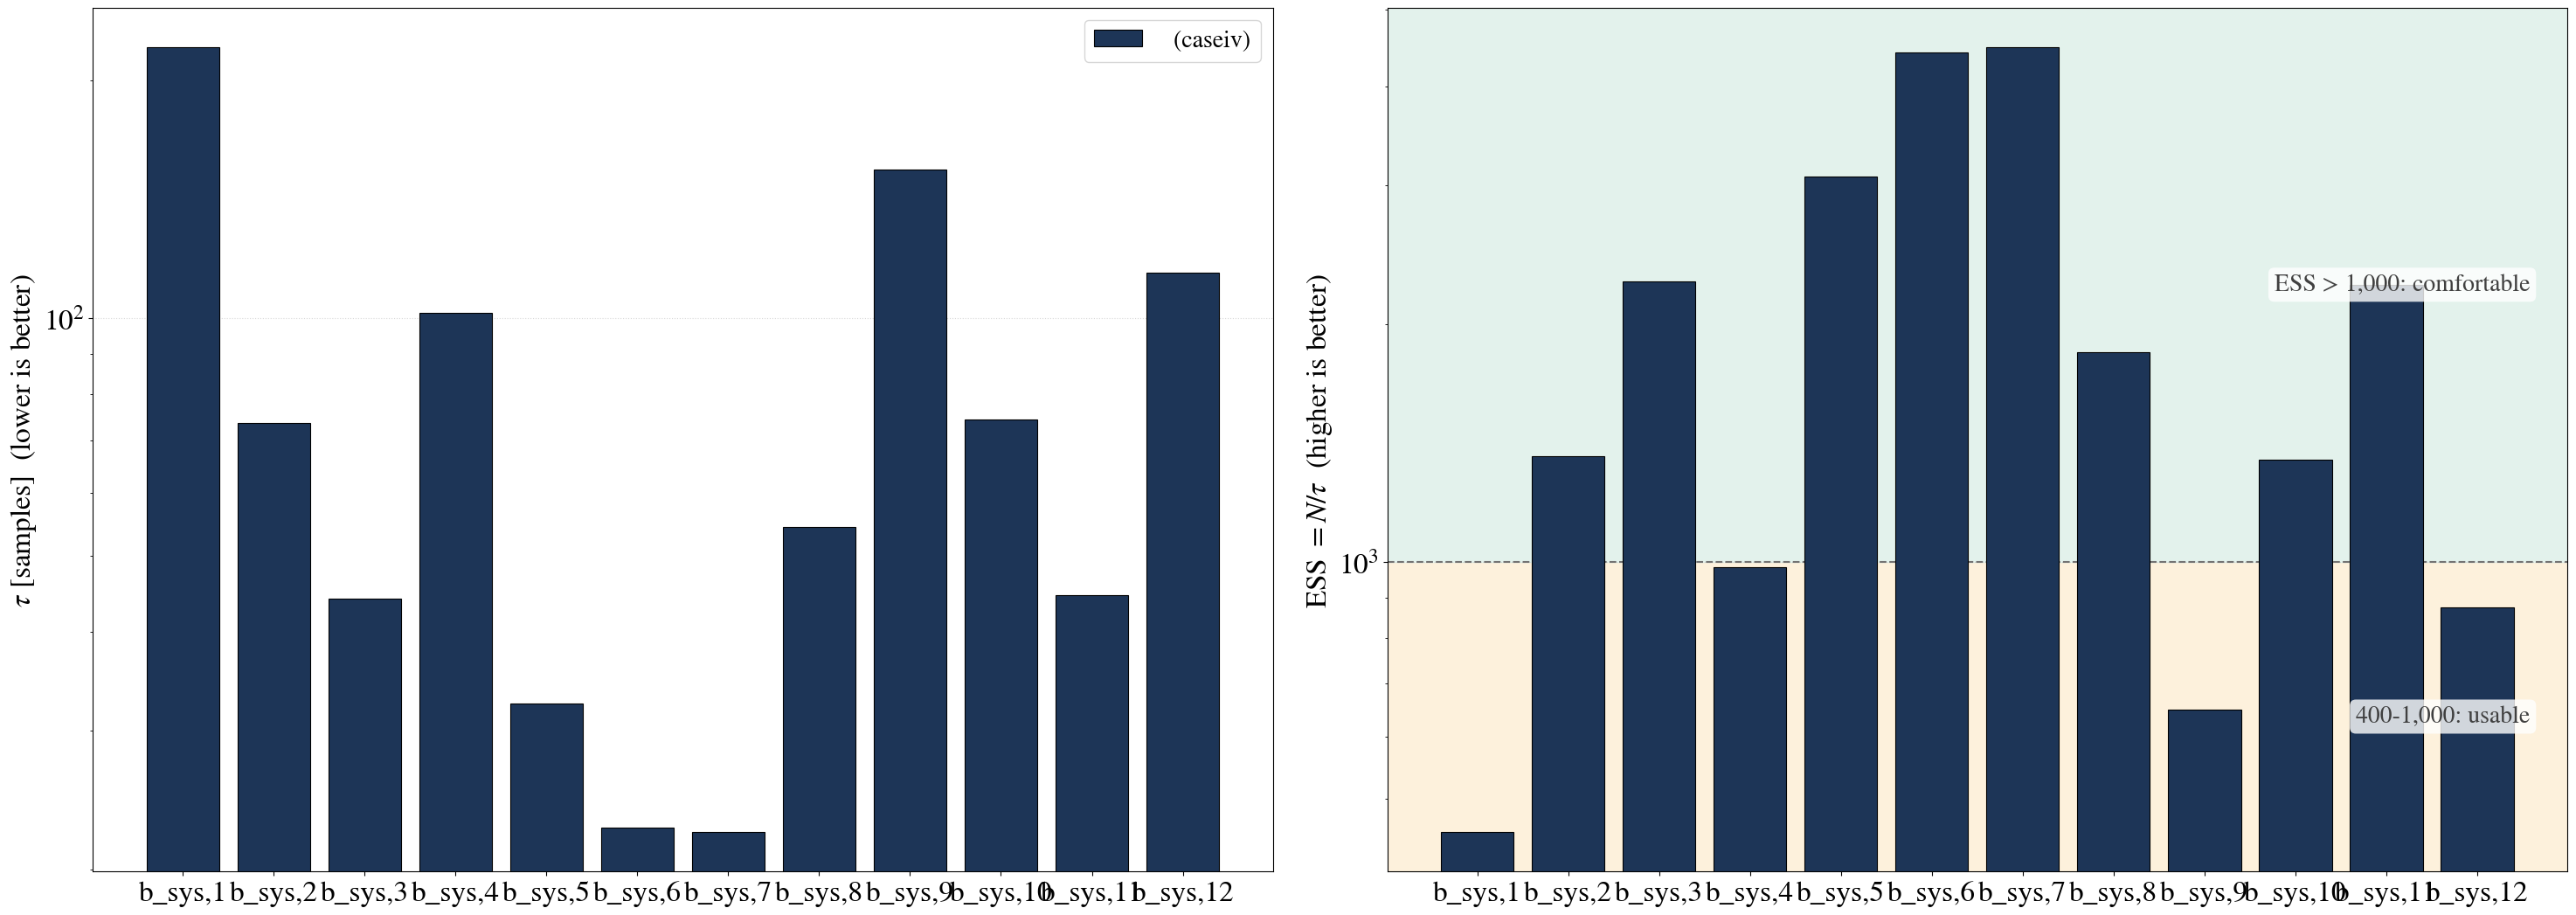

In [ ]:
fig = tbl.plot_ess_tau(table1, colors=colors, figsize=(30, 11))
plt.savefig(fig_dir + '/ess_tau_bsys.pdf', bbox_inches='tight', dpi=300)

# Markdown / LaTeX / CSV / HTML copies of the table, ready to send on.
tbl.save_tables(fig_dir + '/tables')


---
# Figure 11: FG–systematics correlation

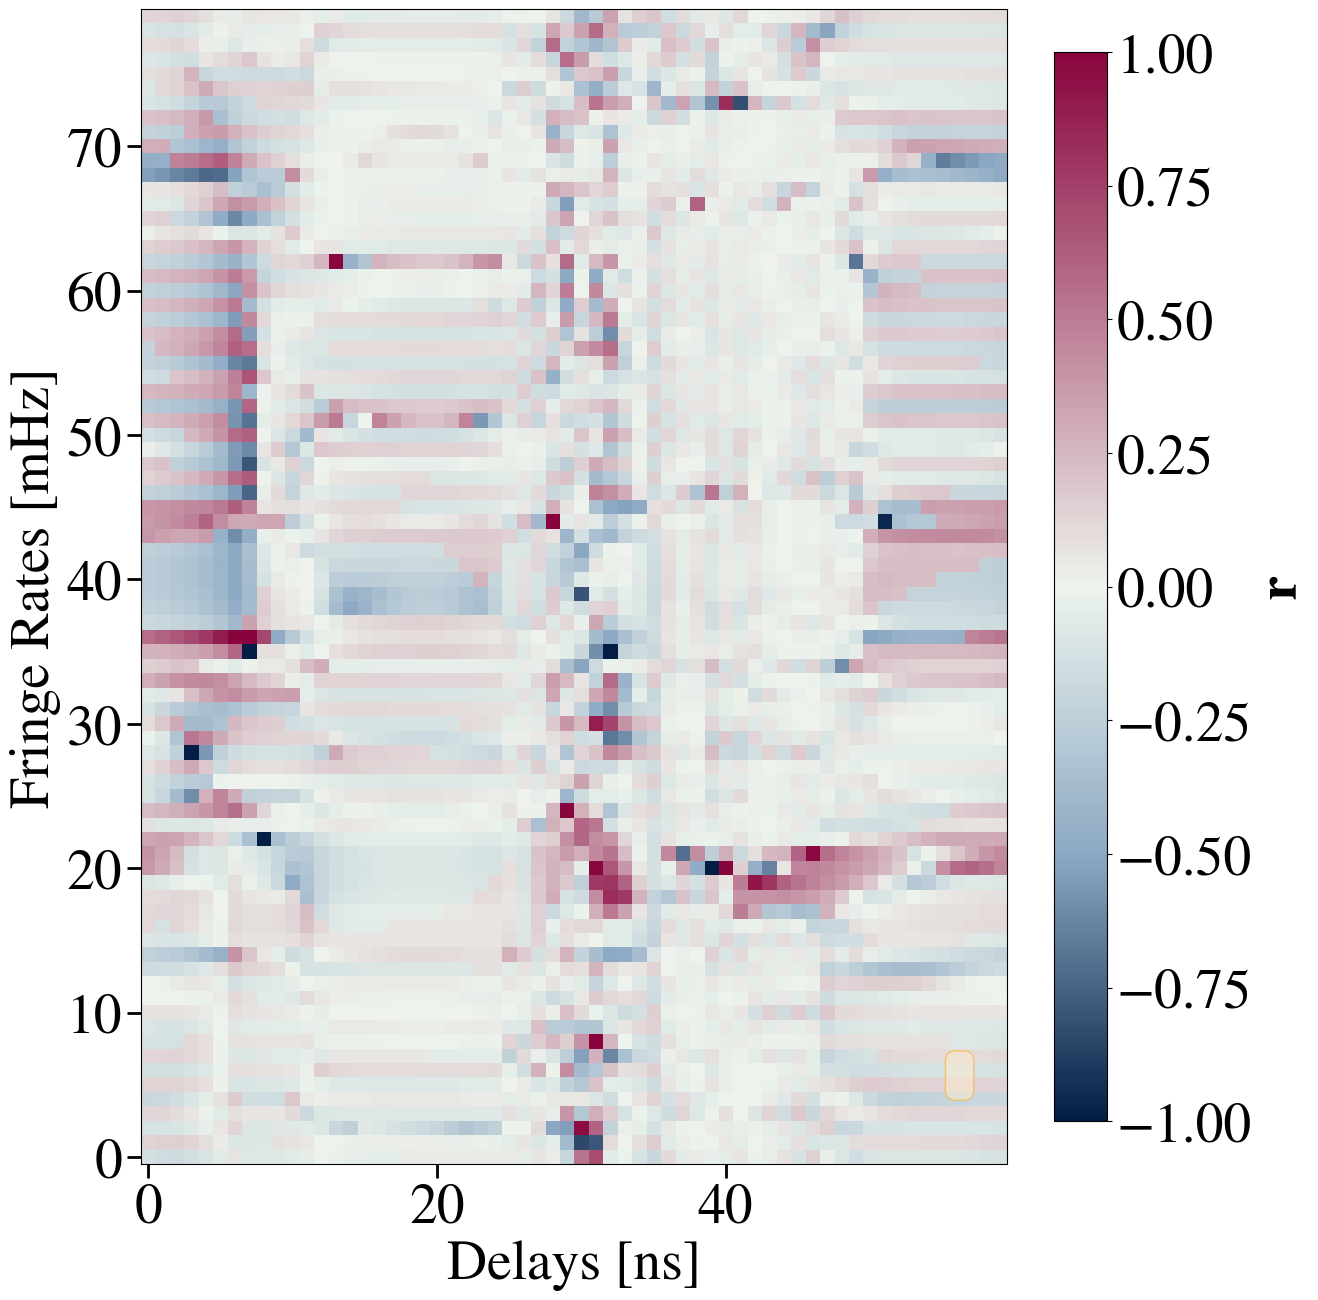

In [ ]:
fig, axs = plt.subplots(1, 1, figsize=(15, 15))

im = axs.imshow(corr_map[::-1, :].real, cmap=paper_map, origin='lower', vmin=-1, vmax=1)
axs.text(0.95, 0.07, case_label, bbox=bbox,
         transform=axs.transAxes, horizontalalignment='right')

cbar = plt.colorbar(im, ax=axs, fraction=0.046, pad=0.04)
cbar.set_label(r'$\mathbf{r}$', size=40)
cbar.ax.tick_params(labelsize=40)

axs.set_xlabel('Delays [ns]', fontsize=40)
axs.set_ylabel('Fringe Rates [mHz]', fontsize=40)
axs.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=40)
# axs.set_xticks(xticklocs, labels=xticklabels_dl, rotation=15)
# axs.set_yticks(yticklocs, labels=yticklabels_fr)

# plt.savefig(fig_dir + '/fg_sys_corr.pdf', bbox_inches='tight', dpi=300)

Combined-case correlation matrix saved


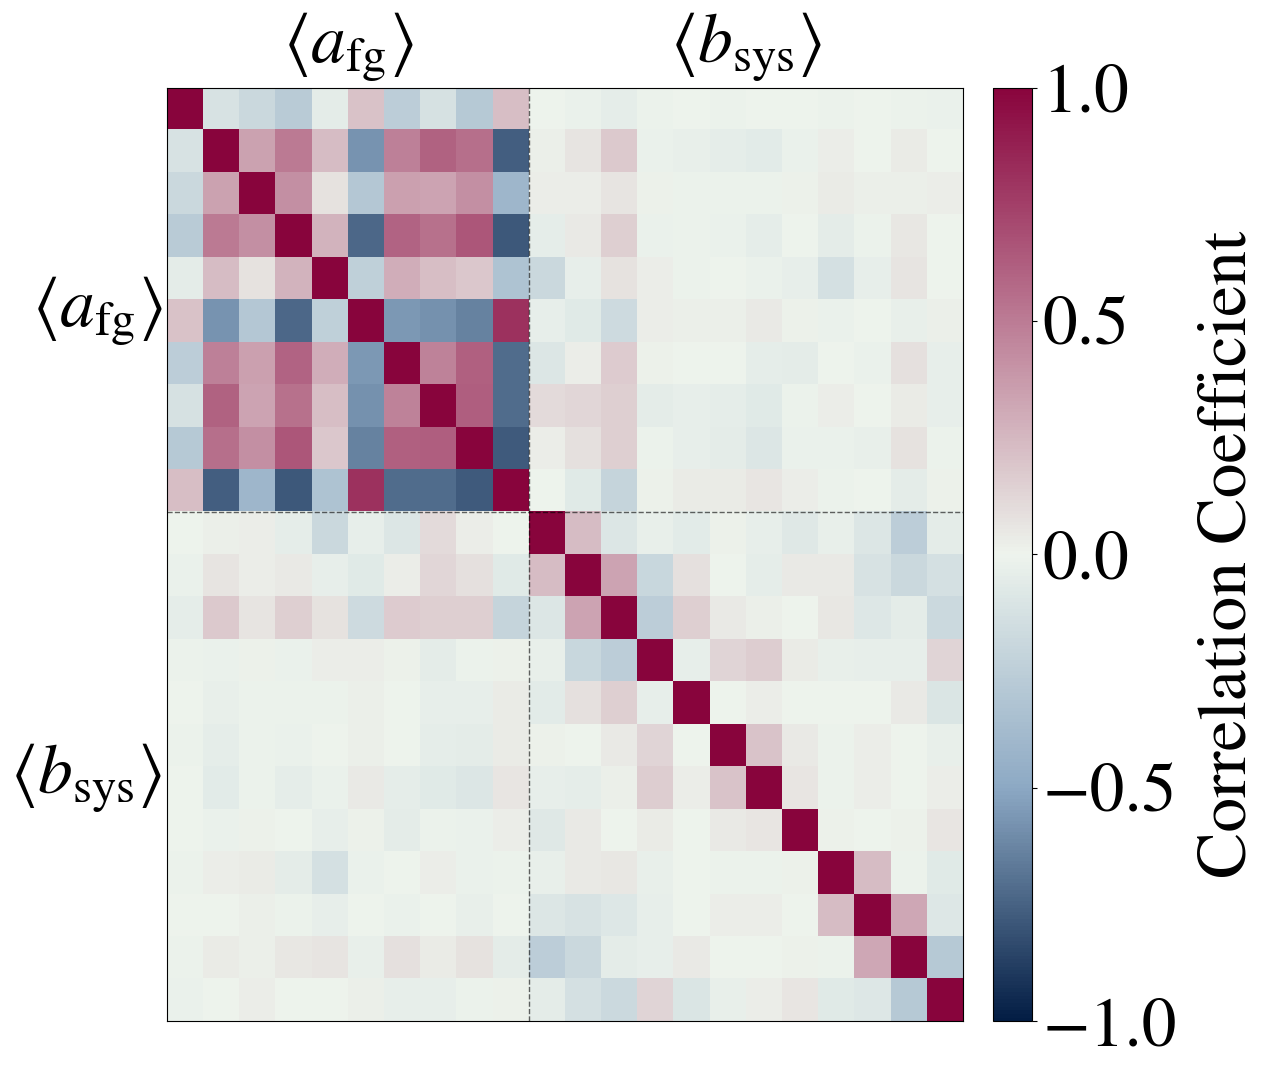

In [ ]:
# Single-panel version of Figure 9 (fig:corr) — for the combined systematics case

def plot_correlation_matrix(corr, ax, param_names, param_sizes, fontsize=40, cmap="RdBu"):
    """
    Plot a formatted correlation matrix into a given Axes object.
    (unchanged from the multi-case version)
    """
    im = ax.matshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect="auto", interpolation="none")

    # --- Block dividing lines ---
    boundaries = np.cumsum(param_sizes)[:-1] - 0.5
    for b in boundaries:
        ax.axhline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)
        ax.axvline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)

    # --- Block centre positions for labels ---
    centres = []
    start = 0
    for size in param_sizes:
        centres.append(start + size / 2 - 0.5)
        start += size

    # --- Axis labels ---
    ax.set_xticks(centres)
    ax.set_xticklabels(
        [rf"$\langle {n} \rangle$" for n in param_names],
        fontsize=fontsize,
    )
    ax.set_yticks(centres)
    ax.set_yticklabels(
        [rf"$\langle {n} \rangle$" for n in param_names],
        fontsize=fontsize,
    )
    ax.tick_params(length=0)

    return im


# --- Usage: single case (the combined case) ---
param_names = [r'a_\text{fg}', r'b_\text{sys}']
param_sizes = [10, 12]
combined_case_label = ' '
fig, ax = plt.subplots(1, 1, figsize=(14, 12))
plt.rcParams.update({'font.size': 50})

fg_flat = np.abs(fg_amps_gcr[:Niter, -3, :]).reshape(Niter, -1)
samples_all = np.concatenate([fg_flat, np.abs(b_sys_gcr[:Niter, :])], axis=1)
corr = np.corrcoef(samples_all, rowvar=False)

im = plot_correlation_matrix(
    corr        = corr,
    ax          = ax,
    param_names = param_names,
    param_sizes = param_sizes,
    cmap        = paper_map,
    fontsize    = 50,
)
# ax.text(0.95, 0.07, combined_case_label, bbox=bbox_res,
#          transform=ax.transAxes, horizontalalignment='right')

# --- Colorbar attached directly to the single Axes ---
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.3)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label(label="Correlation Coefficient", fontsize=50, labelpad=15)
cax.yaxis.label.set_size(50)
cax.tick_params(labelsize=50)

fig.tight_layout()
plt.savefig(fig_dir + '/multi_corr.pdf', bbox_inches='tight', dpi=300)
print("Combined-case correlation matrix saved")

In [ ]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f"Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s")

Total notebook runtime: 00h 10m 55.4s
